<a href="https://colab.research.google.com/github/YonghwanYim/CMAPSS-Experiments/blob/main/ML_Exp_4_failure_probability_10_dataset_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning + RL
(NASA C-MAPSS dataset)

**2023.12.26 Meeting**

Directed Loss function 추가 후 실험.

# Data Handling

Connect with Google Drive

In [2]:
from google.colab import drive
drive.mount('content')

Drive already mounted at content; to attempt to forcibly remount, call drive.mount("content", force_remount=True).


Importing libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import sklearn
from sklearn.metrics import mean_squared_error, r2_score
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import random
import warnings
np.random.seed(34)
warnings.filterwarnings('ignore')

Defining features names

In [4]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i+1) for i in range(0,21)]
col_names = index_names + setting_names + sensor_names

In [5]:
dftrain = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/train_FD003_1_70.txt',sep='\s+',header=None,index_col=False,names=col_names)
dfvalid = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/train_FD003_71_100.txt',sep='\s+',header=None,index_col=False,names=col_names)
dffull_data = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/train_FD003.txt',sep='\s+',header=None,index_col=False,names=col_names)
# y_valid : A vector of true Remaining Useful Life (RUL) values for the test data.
# y_valid = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/RUL_FD001.txt',sep='\s+',header=None,index_col=False,names=['RUL'])
# dfvalid.shape

특정 확률만큼 랜덤 샘플 추출 (관측 확률을 반영).


In [6]:
N = 20                  # number of sample.
obs_probability = 0.1  # 관측확률 : 0.1이면 10% 확률로 관측 가능하니 나머지 데이터 90%를 날리는 것을 의미함.

# 샘플링 결과 저장할 list 초기화
sampled_data_list = []

# 반복문을 통해 N번의 샘플링 수행
# random_state는 재현 가능성을 위해 사용되는 시드. 동일 시드 = 동일 샘플
for i in range(N):
    # 샘플링 수행
    sampled_dftrain = dftrain.sample(frac=obs_probability, random_state=i+10)
    sampled_dfvalid = dfvalid.sample(frac=obs_probability, random_state=i+10)
    sampled_dffull_data = dffull_data.sample(frac=obs_probability, random_state=i+10)

    # 데이터 정렬
    sampled_dftrain = sampled_dftrain.sort_values(by=['unit_number', 'time_cycles'])
    sampled_dfvalid = sampled_dfvalid.sort_values(by=['unit_number', 'time_cycles'])
    sampled_dffull_data = sampled_dffull_data.sort_values(by=['unit_number', 'time_cycles'])

    # 샘플링 결과를 리스트에 추가
    sampled_data_list.append((sampled_dftrain.copy(), sampled_dfvalid.copy(), sampled_dffull_data.copy()))

sampled dataset 확인

In [7]:
for i, (sampled_dftrain, sampled_dfvalid, sampled_dffull_data) in enumerate(sampled_data_list, start=1):
    print(f"Sampled Data {i}:")
    print("Sampled Train Data:")
    print(sampled_dftrain.head())
    print("Sampled Valid Data:")
    print(sampled_dfvalid.head())
    print("Sampled Full Data:")
    print(sampled_dffull_data.head())

Sampled Data 1:
Sampled Train Data:
    unit_number  time_cycles  setting_1  setting_2  setting_3     s_1     s_2  \
9             1           10     0.0019    -0.0002      100.0  518.67  642.42   
16            1           17    -0.0019     0.0001      100.0  518.67  641.90   
40            1           41    -0.0014    -0.0002      100.0  518.67  641.96   
42            1           43     0.0009     0.0004      100.0  518.67  642.71   
48            1           49     0.0030    -0.0004      100.0  518.67  642.37   

        s_3      s_4    s_5  ...    s_12     s_13     s_14    s_15  s_16  \
9   1587.39  1402.25  14.62  ...  521.96  2387.99  8152.86  8.3987  0.03   
16  1591.12  1395.08  14.62  ...  521.98  2387.93  8154.66  8.3761  0.03   
40  1582.54  1400.72  14.62  ...  522.45  2387.97  8151.32  8.3559  0.03   
42  1581.49  1399.38  14.62  ...  522.42  2387.98  8144.75  8.4327  0.03   
48  1586.75  1393.83  14.62  ...  521.94  2388.01  8149.51  8.3804  0.03   

    s_17  s_18   s_1

**1번 샘플에 대해 코드 실행.**

In [8]:
train = sampled_data_list[0][0].copy()
valid = sampled_data_list[0][1].copy()
full_data = sampled_data_list[0][2].copy()

Add RUL column to the data

RUL corresponds to the remaining time cycles for each unit before it falls.

In [9]:
def add_RUL_column(df):
    train_grouped_by_unit = df.groupby(by='unit_number')
    max_time_cycles = train_grouped_by_unit['time_cycles'].max()
    merged = df.merge(max_time_cycles.to_frame(name='max_time_cycle'), left_on='unit_number',right_index=True)
    merged["RUL"] = merged["max_time_cycle"] - merged['time_cycles']
    merged = merged.drop("max_time_cycle", axis=1)
    return merged

In [10]:
train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

In [11]:
train

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
9,1,10,0.0019,-0.0002,100.0,518.67,642.42,1587.39,1402.25,14.62,...,2387.99,8152.86,8.3987,0.03,391,2388,100.0,38.94,23.4781,222
16,1,17,-0.0019,0.0001,100.0,518.67,641.90,1591.12,1395.08,14.62,...,2387.93,8154.66,8.3761,0.03,393,2388,100.0,39.04,23.3718,215
40,1,41,-0.0014,-0.0002,100.0,518.67,641.96,1582.54,1400.72,14.62,...,2387.97,8151.32,8.3559,0.03,392,2388,100.0,39.07,23.3239,191
42,1,43,0.0009,0.0004,100.0,518.67,642.71,1581.49,1399.38,14.62,...,2387.98,8144.75,8.4327,0.03,392,2388,100.0,39.14,23.4357,189
48,1,49,0.0030,-0.0004,100.0,518.67,642.37,1586.75,1393.83,14.62,...,2388.01,8149.51,8.3804,0.03,390,2388,100.0,38.92,23.3822,183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17458,70,102,-0.0003,0.0000,100.0,518.67,642.50,1589.35,1401.58,14.62,...,2388.05,8146.13,8.4124,0.03,394,2388,100.0,38.69,23.3472,69
17478,70,122,-0.0011,0.0001,100.0,518.67,642.93,1585.26,1403.65,14.62,...,2388.11,8142.97,8.4255,0.03,394,2388,100.0,38.84,23.3336,49
17495,70,139,-0.0003,-0.0001,100.0,518.67,642.75,1599.18,1418.52,14.62,...,2388.06,8144.69,8.4737,0.03,395,2388,100.0,38.73,23.3578,32
17518,70,162,-0.0039,-0.0000,100.0,518.67,643.42,1598.17,1417.43,14.62,...,2388.26,8140.88,8.4884,0.03,395,2388,100.0,38.62,23.1397,9


In [12]:
Sensor_dictionary={}
dict_list=[ "(Fan inlet temperature) (◦R)",
"(LPC outlet temperature) (◦R)",
"(HPC outlet temperature) (◦R)",
"(LPT outlet temperature) (◦R)",
"(Fan inlet Pressure) (psia)",
"(bypass-duct pressure) (psia)",
"(HPC outlet pressure) (psia)",
"(Physical fan speed) (rpm)",
"(Physical core speed) (rpm)",
"(Engine pressure ratio(P50/P2)",
"(HPC outlet Static pressure) (psia)",
"(Ratio of fuel flow to Ps30) (pps/psia)",
"(Corrected fan speed) (rpm)",
"(Corrected core speed) (rpm)",
"(Bypass Ratio) ",
"(Burner fuel-air ratio)",
"(Bleed Enthalpy)",
"(Required fan speed)",
"(Required fan conversion speed)",
"(High-pressure turbines Cool air flow)",
"(Low-pressure turbines Cool air flow)" ]
i=1
for x in dict_list :
    Sensor_dictionary['s_'+str(i)]=x
    i+=1
Sensor_dictionary

{'s_1': '(Fan inlet temperature) (◦R)',
 's_2': '(LPC outlet temperature) (◦R)',
 's_3': '(HPC outlet temperature) (◦R)',
 's_4': '(LPT outlet temperature) (◦R)',
 's_5': '(Fan inlet Pressure) (psia)',
 's_6': '(bypass-duct pressure) (psia)',
 's_7': '(HPC outlet pressure) (psia)',
 's_8': '(Physical fan speed) (rpm)',
 's_9': '(Physical core speed) (rpm)',
 's_10': '(Engine pressure ratio(P50/P2)',
 's_11': '(HPC outlet Static pressure) (psia)',
 's_12': '(Ratio of fuel flow to Ps30) (pps/psia)',
 's_13': '(Corrected fan speed) (rpm)',
 's_14': '(Corrected core speed) (rpm)',
 's_15': '(Bypass Ratio) ',
 's_16': '(Burner fuel-air ratio)',
 's_17': '(Bleed Enthalpy)',
 's_18': '(Required fan speed)',
 's_19': '(Required fan conversion speed)',
 's_20': '(High-pressure turbines Cool air flow)',
 's_21': '(Low-pressure turbines Cool air flow)'}

Plotting the evolution of features (sensors) along with the evolution with RUL

In [13]:
def plot_signal(df, Sensor_dic, signal_name):
    plt.figure(figsize=(13,5))
    for i in df['unit_number'].unique():
      #plt.plot('RUL', signal_name, data=df[df['unit_number']==i].rolling(10).mean())
       if (i % 5 == 0):   #For a better visualisation, we plot the sensors signals of 10 units only (data : FD001)
           plt.plot('RUL', signal_name, data=df[df['unit_number']==i].rolling(10).mean())

    plt.xlim(250, 0)  # reverse the x-axis so RUL counts down to zero  # xlim() : range of x-axis
    plt.xticks(np.arange(0, 300, 25))
    plt.ylabel(Sensor_dic[signal_name])
    plt.xlabel('Remaining Useful Life')
    plt.show()

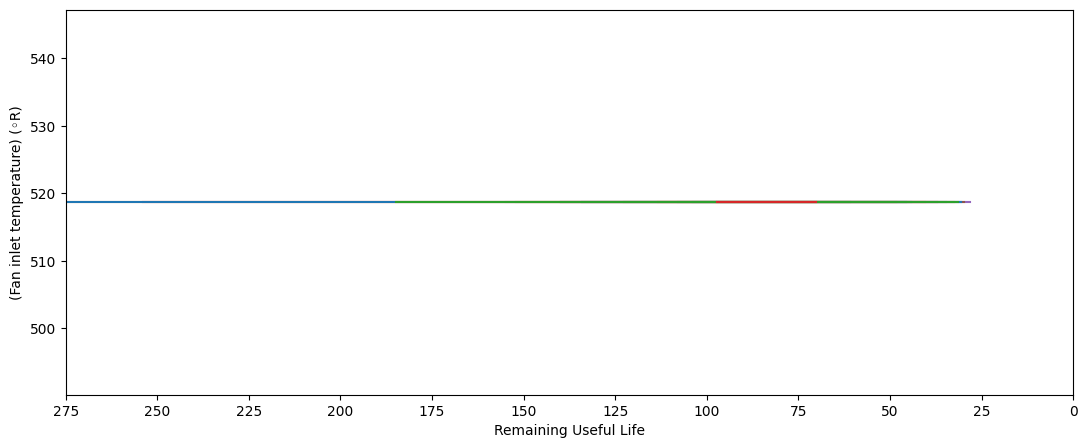

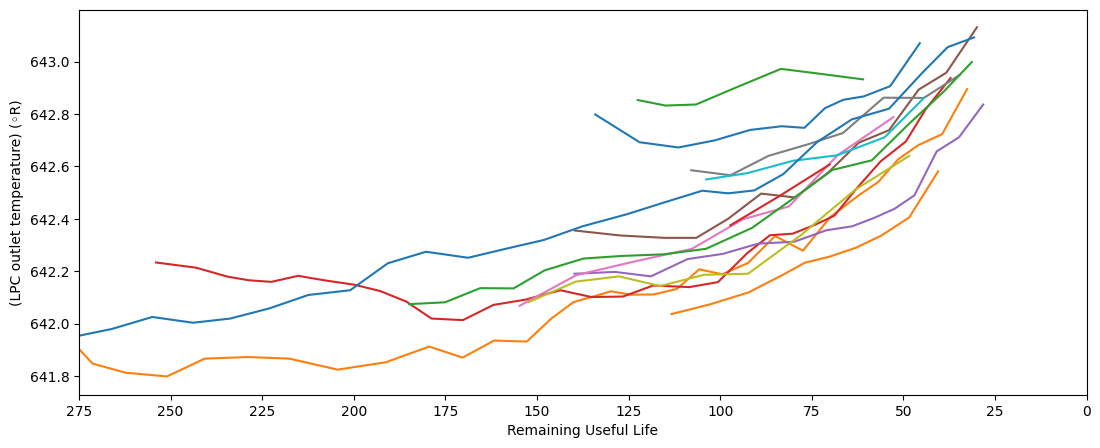

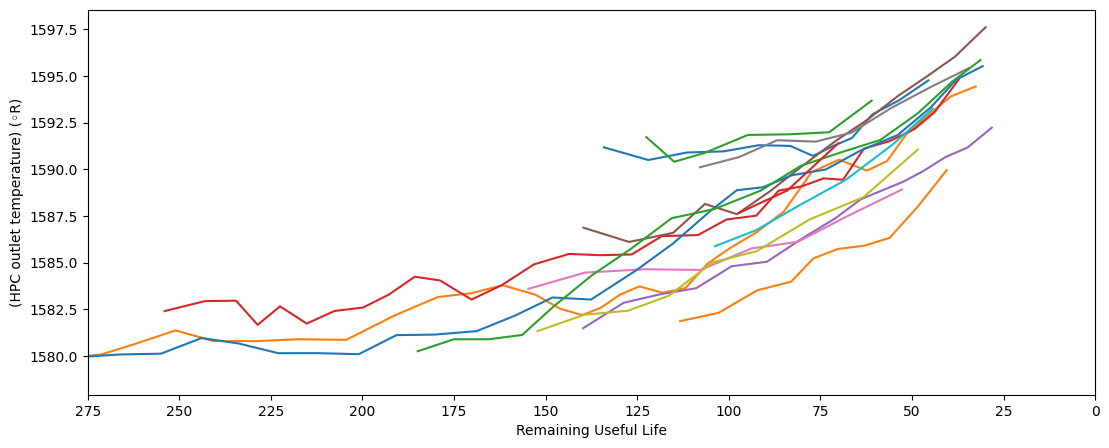

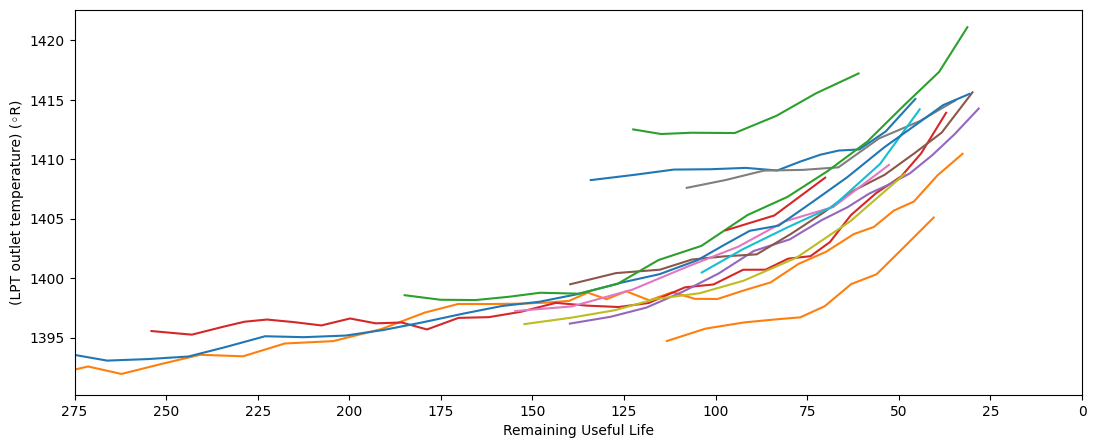

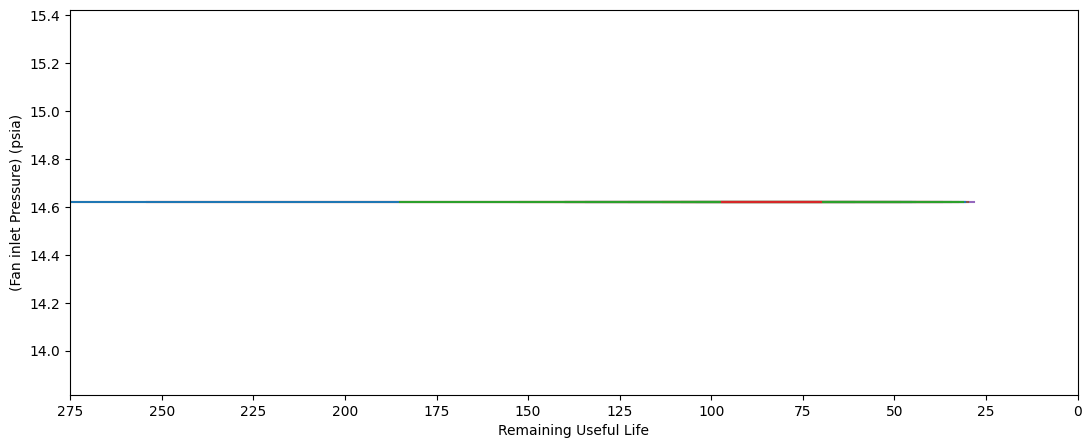

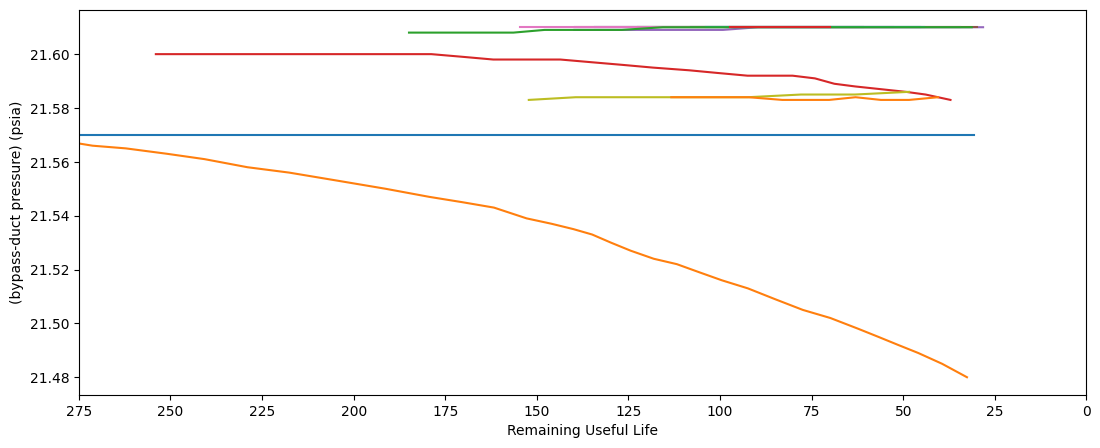

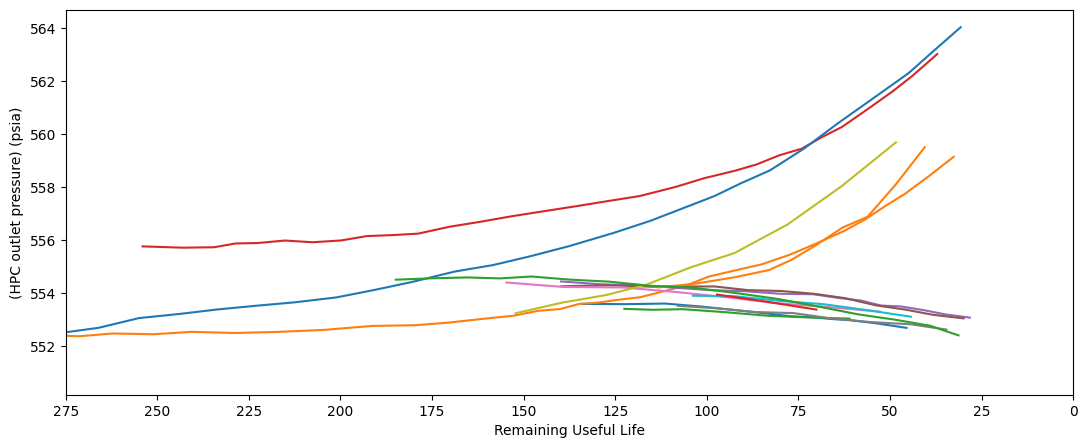

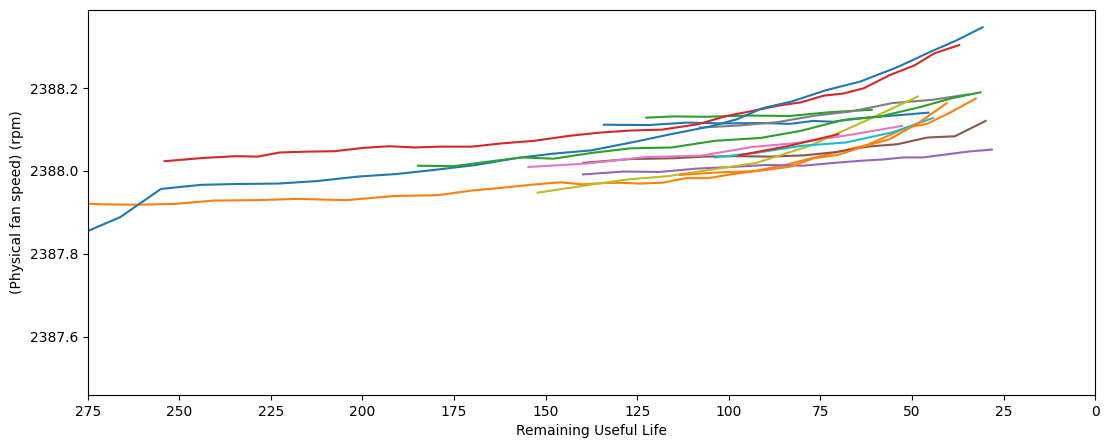

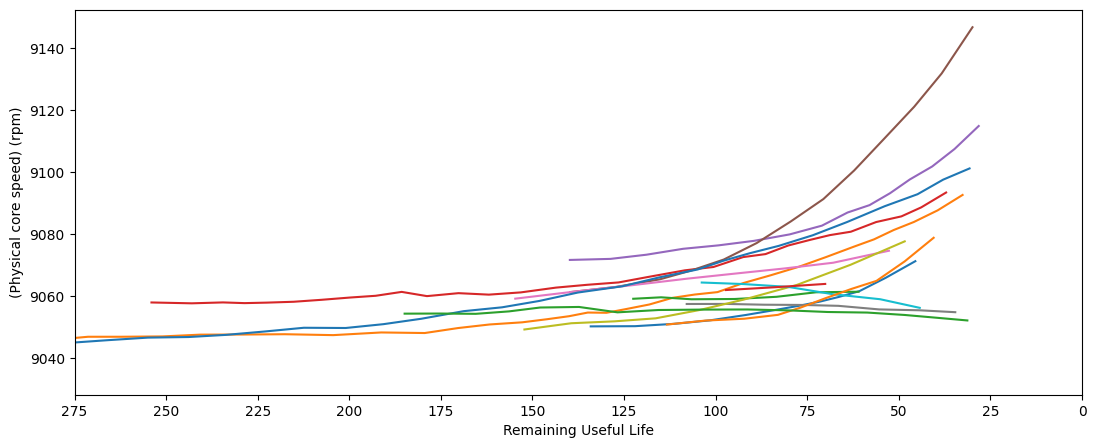

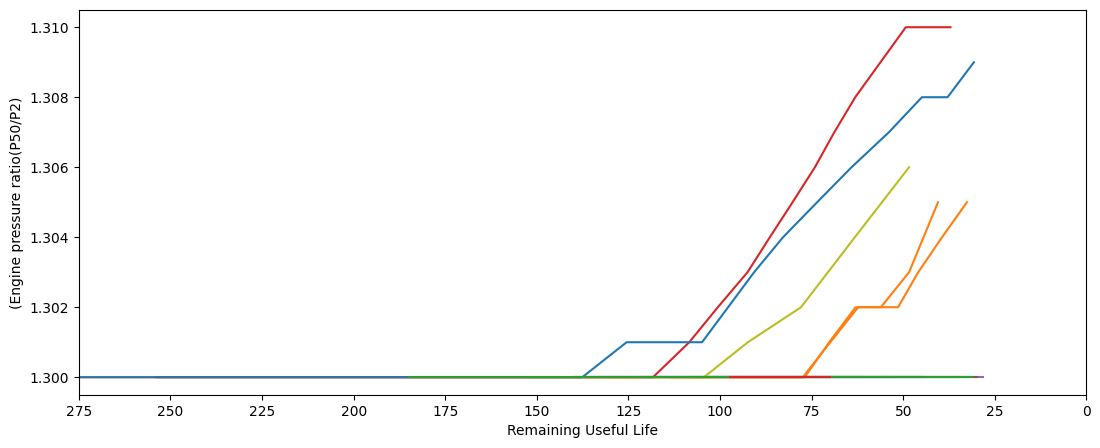

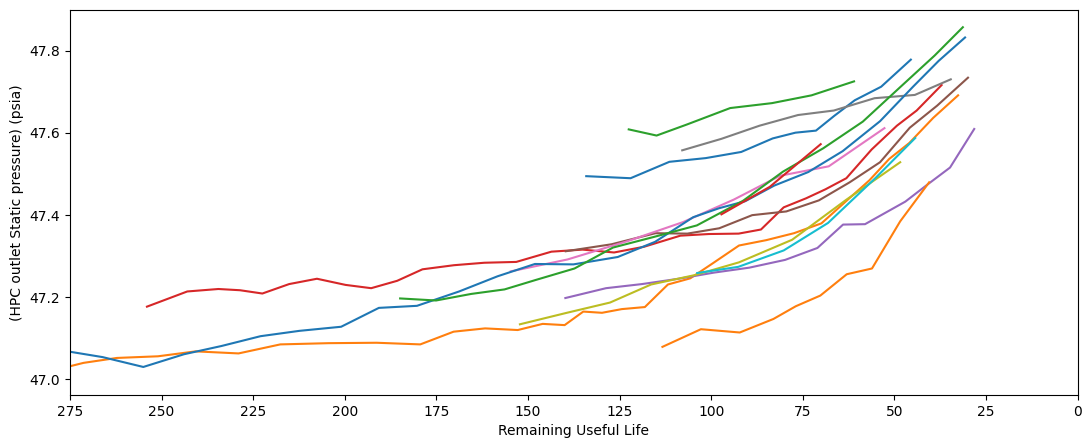

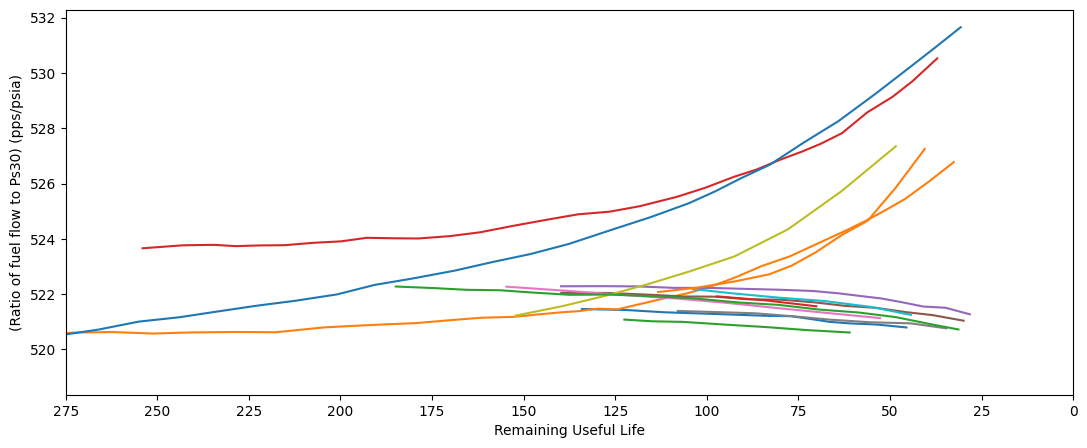

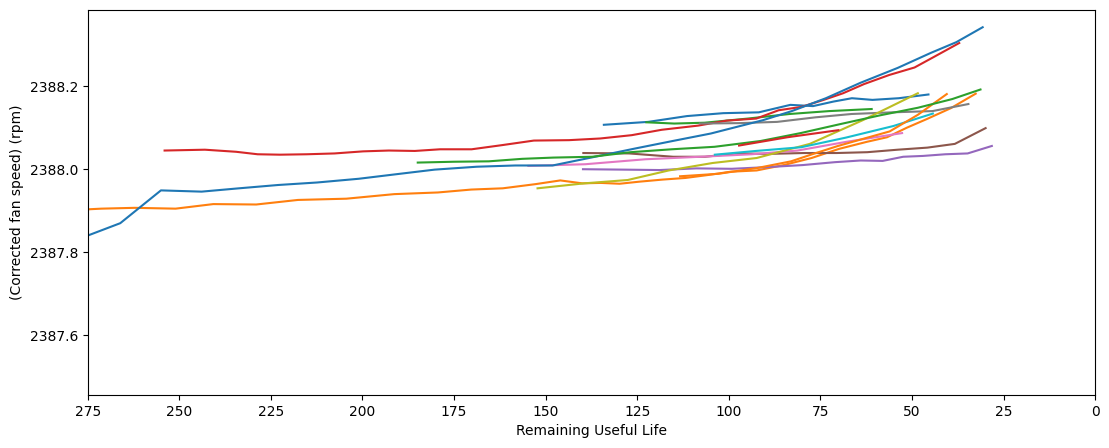

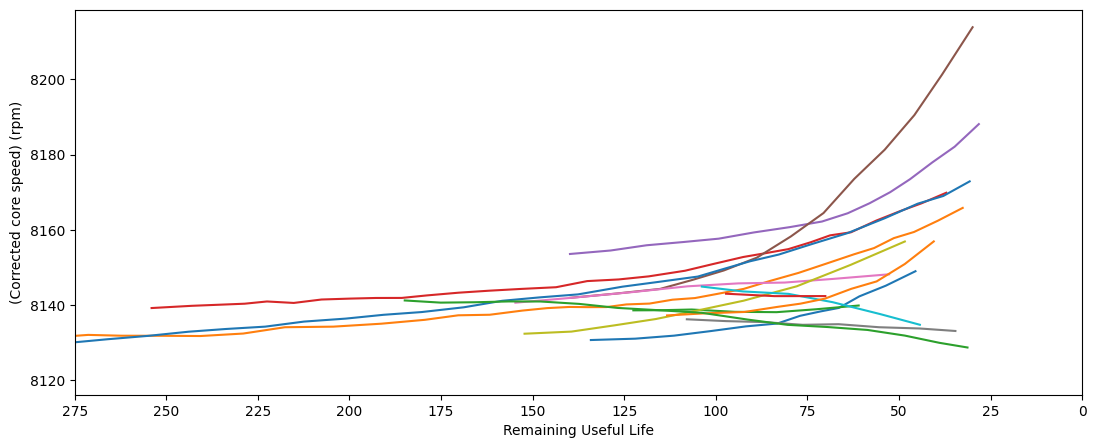

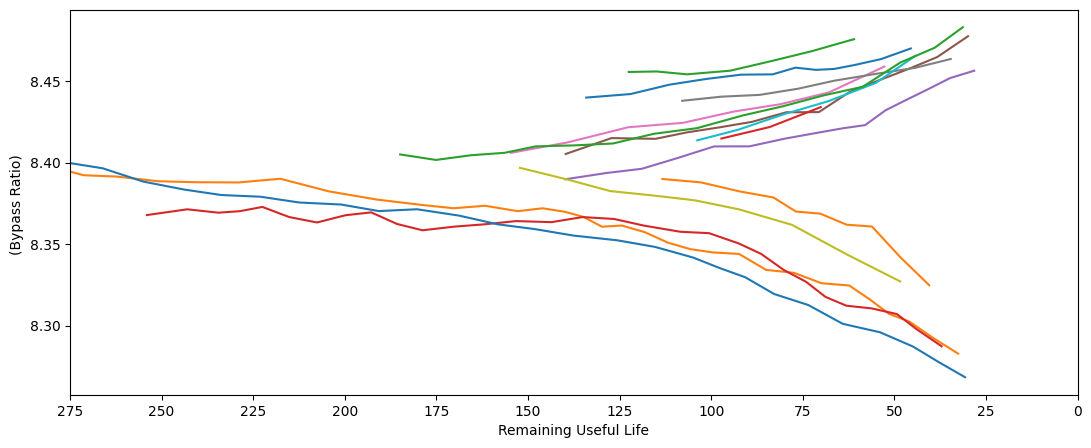

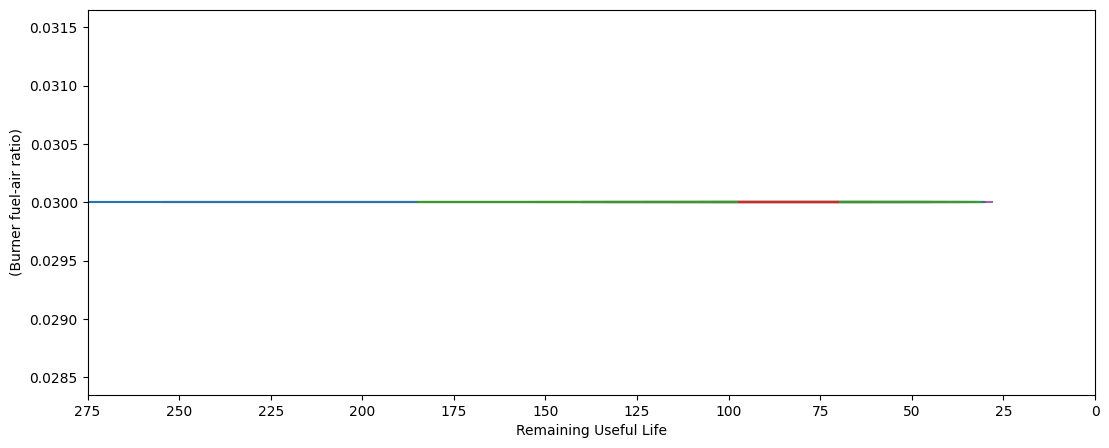

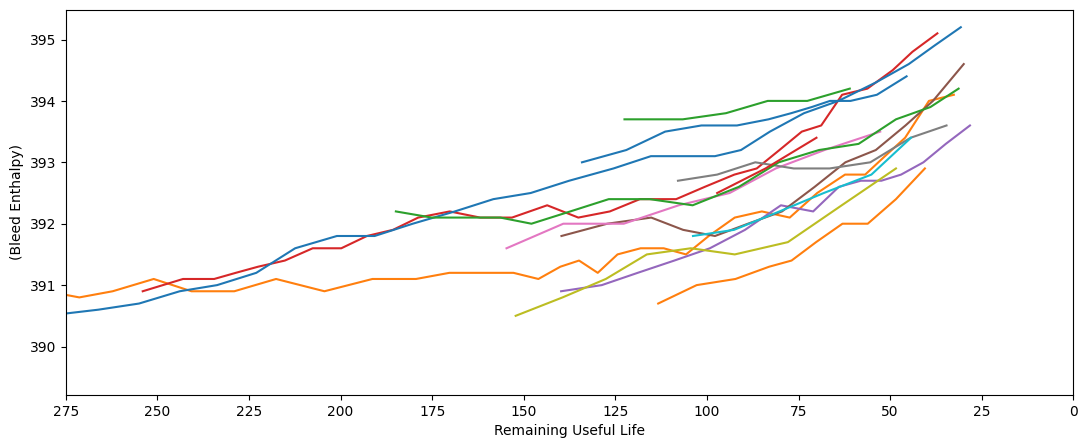

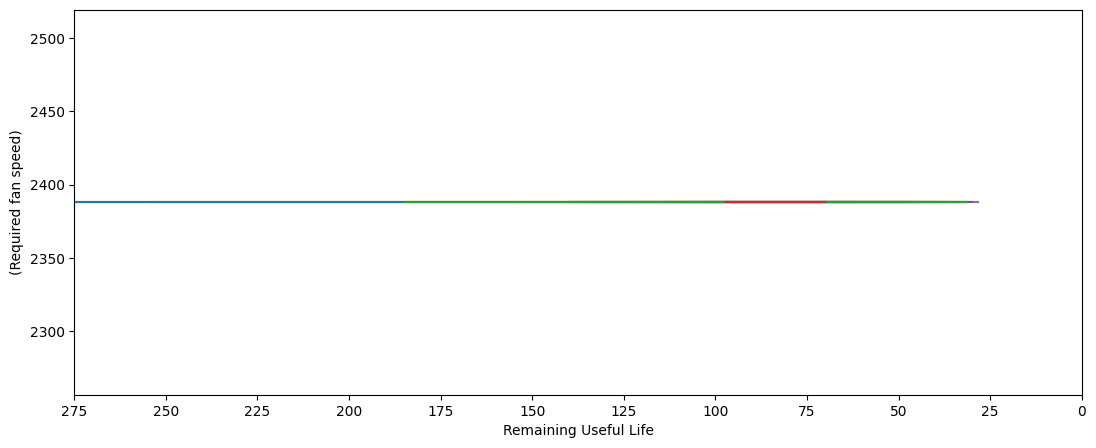

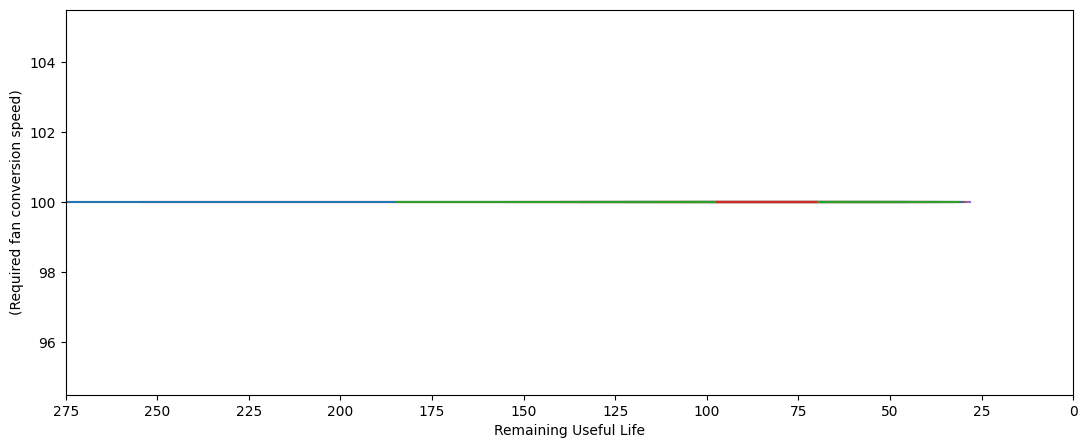

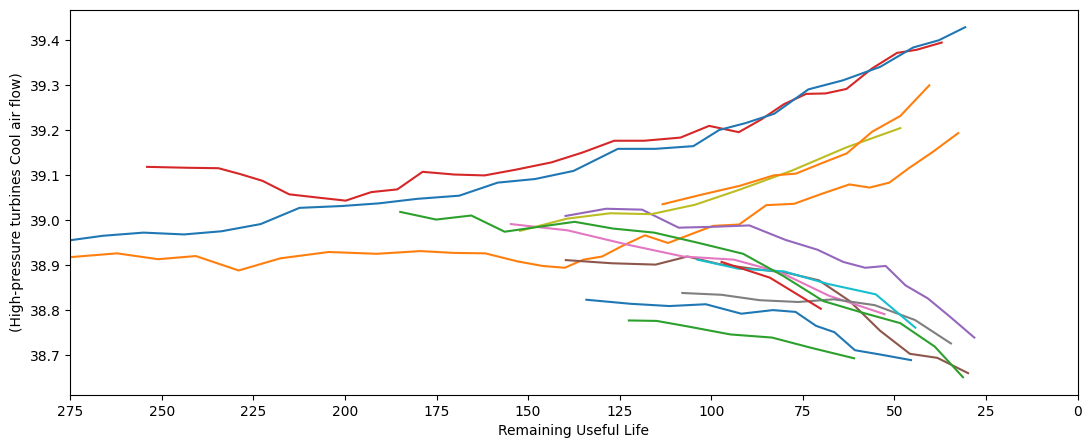

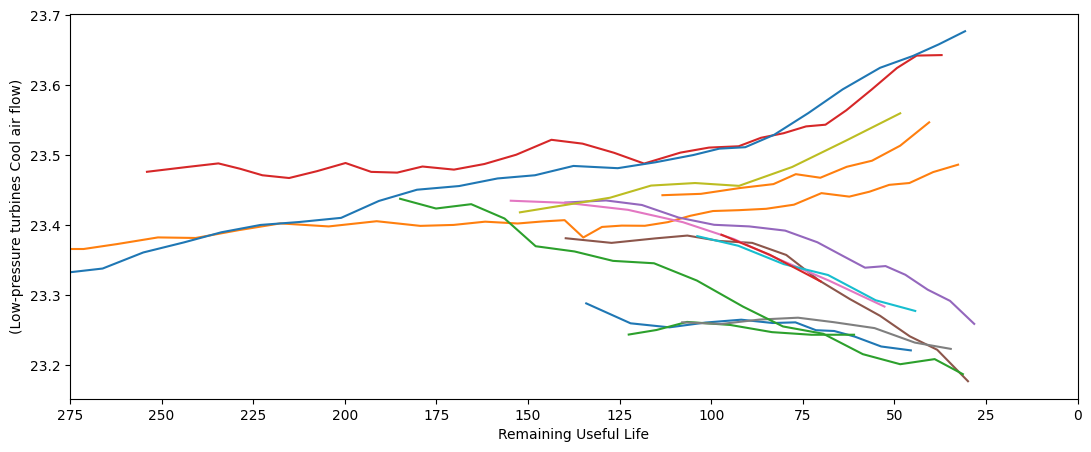

In [14]:
for i in range(1,22):
    try:
        plot_signal(train, Sensor_dictionary,'s_'+str(i))
    except:
        pass

MinMax scaler function : Transform features by scaling each feature to a given range.

This estimater scales and translates each feature individually such that it is in the given range on the training set

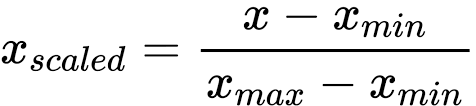

Dropping unnecessary features (labels and settings)

In [15]:
from sklearn.model_selection import train_test_split
drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()

Scaling the data

In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

In [17]:
print(X_train)

          s_1     s_2      s_3      s_4    s_5    s_6     s_7      s_8  \
9      518.67  642.42  1587.39  1402.25  14.62  21.61  554.78  2387.99   
16     518.67  641.90  1591.12  1395.08  14.62  21.61  555.06  2388.00   
40     518.67  641.96  1582.54  1400.72  14.62  21.60  554.61  2387.97   
42     518.67  642.71  1581.49  1399.38  14.62  21.61  553.96  2387.96   
48     518.67  642.37  1586.75  1393.83  14.62  21.61  553.91  2388.04   
...       ...     ...      ...      ...    ...    ...     ...      ...   
17258  518.67  642.97  1590.39  1417.43  14.62  21.61  553.43  2388.12   
17261  518.67  642.66  1593.70  1407.00  14.62  21.61  553.03  2388.11   
17272  518.67  642.44  1591.05  1413.82  14.62  21.61  553.58  2388.18   
17279  518.67  642.73  1594.03  1405.96  14.62  21.61  552.94  2388.14   
17291  518.67  642.56  1592.94  1421.21  14.62  21.61  553.06  2388.17   

           s_9  s_10  ...    s_12     s_13     s_14    s_15  s_16  s_17  s_18  \
9      9070.04   1.3  ...  521

In [18]:
print(X_train_s)

[[0.         0.40460526 0.41113586 ... 0.         0.47435897 0.57157785]
 [0.         0.23355263 0.49420935 ... 0.         0.53846154 0.46050157]
 [0.         0.25328947 0.30311804 ... 0.         0.55769231 0.41044932]
 ...
 [0.         0.41118421 0.49265033 ... 0.         0.43589744 0.29477534]
 [0.         0.50657895 0.55902004 ... 0.         0.35897436 0.31222571]
 [0.         0.45065789 0.53474388 ... 0.         0.32692308 0.30731452]]


In [19]:
print(X_valid_s.shape)
print(y_valid.shape)
print(X_valid)
print(X_valid_s)

(719, 21)
(719, 1)
         s_1     s_2      s_3      s_4    s_5    s_6     s_7      s_8  \
28    518.67  642.09  1583.18  1402.15  14.62  21.57  551.64  2387.42   
40    518.67  641.79  1576.82  1393.51  14.62  21.57  550.75  2387.40   
42    518.67  642.45  1583.73  1397.26  14.62  21.57  551.54  2387.70   
46    518.67  641.68  1583.07  1401.81  14.62  21.57  550.65  2387.74   
66    518.67  641.70  1582.33  1401.42  14.62  21.57  550.91  2387.40   
...      ...     ...      ...      ...    ...    ...     ...      ...   
7140  518.67  642.45  1595.61  1411.08  14.62  21.61  553.39  2388.10   
7141  518.67  643.04  1593.66  1411.78  14.62  21.61  553.73  2388.18   
7147  518.67  643.05  1588.31  1417.42  14.62  21.61  552.53  2388.14   
7171  518.67  643.73  1592.38  1425.19  14.62  21.61  553.03  2388.20   
7183  518.67  643.79  1607.83  1423.08  14.62  21.61  551.59  2388.25   

          s_9  s_10  ...    s_12     s_13     s_14    s_15  s_16  s_17  s_18  \
28    9037.64  1.29  ...

In [20]:
print(y_valid)

      RUL
28    366
40    354
42    352
46    348
66    328
...   ...
7140   43
7141   42
7147   36
7171   12
7183    0

[719 rows x 1 columns]


Plotting features new distribution

# Model Implementation

Linear regression

Defining evaluation functions

In [21]:
# R2 score & RMSE & MSE
def evaluate(y_true, y_hat, label='test'):
    mse = mean_squared_error(y_true, y_hat)
    rmse = np.sqrt(mse)
    variance = r2_score(y_true, y_hat) # R2 score (R-squared) : indep. var.이 depend. var.을 얼마나 잘 설명하는가 (회귀모델 평가지표)
    print('{} set RMSE:{}, R2:{}'.format(label, rmse, variance))

In [22]:
# plot real data and the predicted one to make some comparison
def plot_predActual(y_test, y_test_hat):

    indices = np.arange(len(y_test_hat))
    wth= 0.6                                # width
    plt.figure(figsize=(70,30))
    true_values = [int(x) for x in y_test.values] # y : RUL
    predicted_values = list(y_test_hat)

    plt.bar(indices, true_values, width=wth,color='b', label='True RUL')
    plt.bar([i for i in indices], predicted_values, width=0.5*wth, color='r', alpha=0.7, label='Predicted RUL')

    plt.legend(prop={'size': 40})
    plt.tick_params(labelsize=40)

    plt.show()

**Use all feature**

In [23]:
print(X_train)

          s_1     s_2      s_3      s_4    s_5    s_6     s_7      s_8  \
9      518.67  642.42  1587.39  1402.25  14.62  21.61  554.78  2387.99   
16     518.67  641.90  1591.12  1395.08  14.62  21.61  555.06  2388.00   
40     518.67  641.96  1582.54  1400.72  14.62  21.60  554.61  2387.97   
42     518.67  642.71  1581.49  1399.38  14.62  21.61  553.96  2387.96   
48     518.67  642.37  1586.75  1393.83  14.62  21.61  553.91  2388.04   
...       ...     ...      ...      ...    ...    ...     ...      ...   
17258  518.67  642.97  1590.39  1417.43  14.62  21.61  553.43  2388.12   
17261  518.67  642.66  1593.70  1407.00  14.62  21.61  553.03  2388.11   
17272  518.67  642.44  1591.05  1413.82  14.62  21.61  553.58  2388.18   
17279  518.67  642.73  1594.03  1405.96  14.62  21.61  552.94  2388.14   
17291  518.67  642.56  1592.94  1421.21  14.62  21.61  553.06  2388.17   

           s_9  s_10  ...    s_12     s_13     s_14    s_15  s_16  s_17  s_18  \
9      9070.04   1.3  ...  521

In [24]:
X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1


**Linear regression**

In [25]:
print(X_train_1_s)
print(X_train_1_s.shape)
print(X_valid_1_s)
print(X_valid_1_s.shape)
print(X_full_1_s)
print(X_full_1_s.shape)

[[0.         0.40460526 0.41113586 ... 0.         0.47435897 0.57157785]
 [0.         0.23355263 0.49420935 ... 0.         0.53846154 0.46050157]
 [0.         0.25328947 0.30311804 ... 0.         0.55769231 0.41044932]
 ...
 [0.         0.41118421 0.49265033 ... 0.         0.43589744 0.29477534]
 [0.         0.50657895 0.55902004 ... 0.         0.35897436 0.31222571]
 [0.         0.45065789 0.53474388 ... 0.         0.32692308 0.30731452]]
(1735, 21)
[[0.         0.30291971 0.28112564 ... 0.         0.29655172 0.30260497]
 [0.         0.19343066 0.1003411  ... 0.         0.26896552 0.31045557]
 [0.         0.43430657 0.29675952 ... 0.         0.26896552 0.30522184]
 ...
 [0.         0.65328467 0.42694713 ... 0.         0.23448276 0.25157607]
 [0.         0.90145985 0.54263786 ... 0.         0.06206897 0.15272987]
 [0.         0.92335766 0.98180785 ... 0.         0.02758621 0.21160937]]
(719, 21)
[[0.         0.31111111 0.43621013 ... 0.         0.53797468 0.55272806]
 [0.         0.207

In [26]:
print(y_train_clip)
print(y_train_clip.shape)

9        195
16       195
40       191
42       189
48       183
        ... 
17258     97
17261     94
17272     83
17279     76
17291     64
Name: RUL, Length: 1735, dtype: int64
(1735,)


# **Loss function Tuning**

**1. Original MSE**

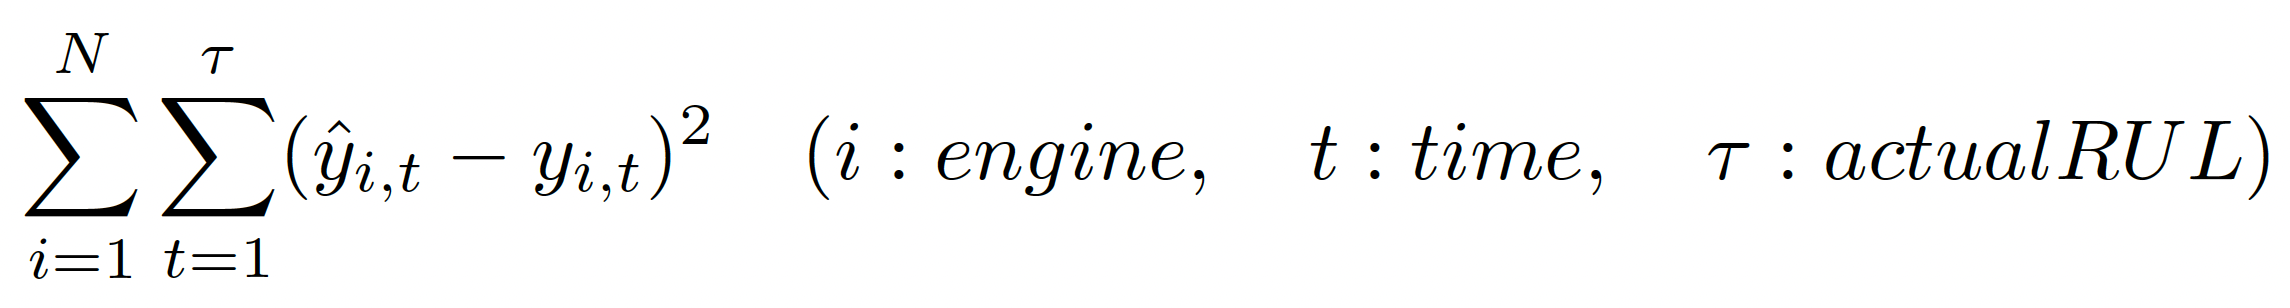

In [27]:

# 1. Original Linear Regression (모든 데이터 사용)
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')

print(lr1.coef_)

train set RMSE:35.342272976410825, R2:0.7158635562814459
valid set RMSE:82.90091067166297, R2:0.2523777421479153
full data set RMSE:73.13536331679333, R2:0.4496789660508964
[ 0.00000000e+00 -2.28024612e+01 -4.64543879e+01 -4.44386729e+01
 -6.39488462e-14  7.32551743e+01  3.35635517e+01 -2.80404787e+01
 -8.98679190e+01 -4.49049871e+01 -8.56276671e+01 -8.46610166e+01
 -6.12046336e+01 -3.50971386e+01 -3.35654697e+01  7.10542736e-15
 -2.27667619e+01  0.00000000e+00  0.00000000e+00  5.82067936e+01
  1.44783065e+01]


**2. Crucial moments Loss function**

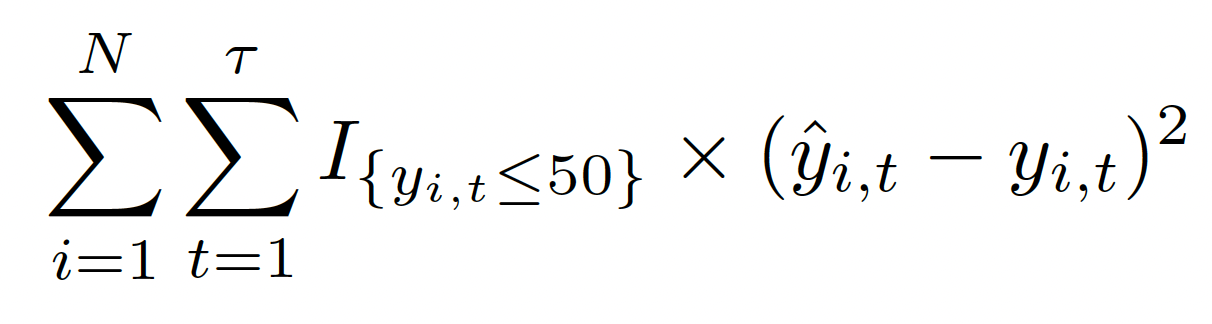

In [28]:
# 2. Crucial moments loss function - Linear Regression

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')

print(lr2.coef_)

train set RMSE:85.44846644920565, R2:-0.6609116532014538
valid set RMSE:118.5755245246909, R2:-0.5295149586949663
full data set RMSE:123.69375874586312, R2:-0.5741888781329822
[ 0.00000000e+00 -1.17543832e+01 -1.80548799e+01 -1.04468540e+01
  3.55271368e-15  5.28910177e+00  4.51851817e+01 -3.13617363e+01
 -2.06910184e+01  9.44475791e+00 -3.49203267e+01 -4.48374179e+01
 -1.68821512e+01 -2.48739736e+00 -1.29352041e+01  7.10542736e-15
 -6.71067998e+00  0.00000000e+00 -8.96831017e-44 -5.06546709e+00
 -4.86445381e+00]


**3. TD Style Loss function (ridge regression)**

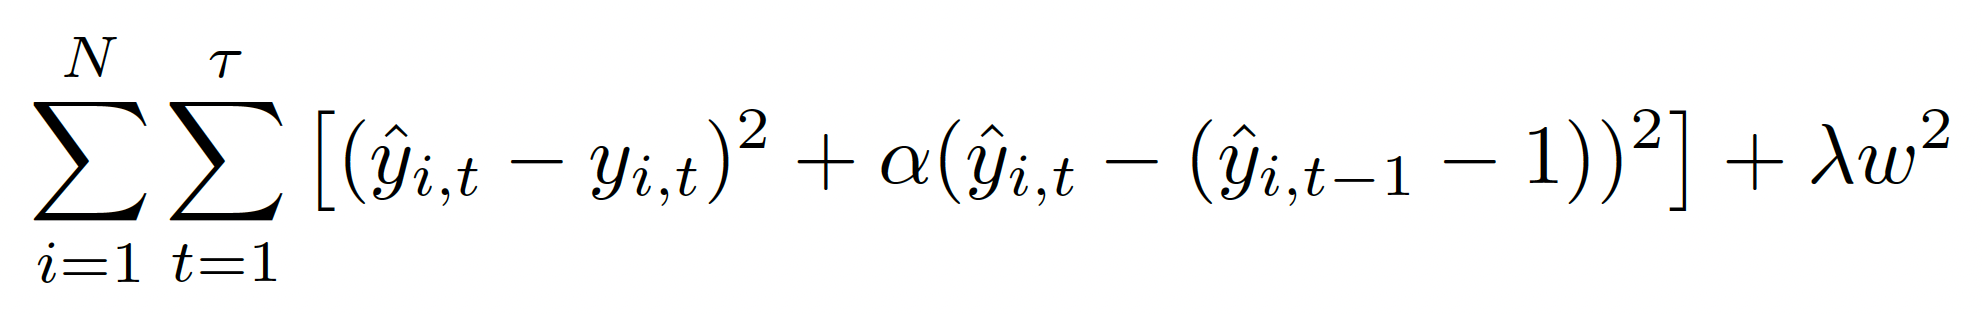

In [29]:
# Multi var linear regression

class Linear_Regression_TD() :
  def __init__( self, alpha=0, lambda_ridge=0 ) :
    self.alpha = alpha
    self.lambda_ridge = lambda_ridge  # Ridge regression

  def fit(self, X, Y, alpha, lambd) :
    self.l, self.p = X.shape
    self.alpha = alpha
    self.lambda_ridge = lambd
    # weight initializer
    self.p = (self.p + 1)         # add constant term.

    self.add_X = np.ones(self.l)
    self.X = np.c_[self.add_X, X]

    self.array_Y = np.array(Y[0:].to_numpy())
    self.array_Y.reshape( self.l, 1 )
    self.Y = self.array_Y
    self.W = np.zeros( self.p ) # W : 0 (b is included)

    self.identity = np.identity( n = self.p ) # Ridge regression
    self.lambda_identity = self.lambda_ridge * self.identity   # lambda * I

    # 각각의 행렬 연산
    X_T_X = (self.X.T) @ (self.X)          # X^(T)X
    X_diff_T_X_diff_sum = np.zeros( [self.p, self.p] )

    for i in range(1, self.l):
      X_diff_T_X_diff = (( self.X[i, :] - self.X[i - 1, :] ).reshape(self.p, 1)) @ (( self.X[i, :] - self.X[i - 1, :] ).reshape(1, self.p))
      X_diff_T_X_diff_sum += X_diff_T_X_diff


    X_T_Y = (self.X.T) @ (self.Y)
    X_T_Y = X_T_Y.reshape( self.p, 1 )
    X_diff_T_sum = np.zeros( [self.p, 1] )

    for i in range(1, self.l):
      X_diff_T = (( self.X[i, :] - self.X[i - 1, :] ).reshape( self.p, 1 ))
      X_diff_T_sum += X_diff_T

    self.W = np.linalg.inv(X_T_X + (self.alpha * X_diff_T_X_diff_sum) + self.lambda_identity) @ (X_T_Y - self.alpha * X_diff_T_sum)

    print(self.W)
    print(self.W.shape)

# X를 입력 받으면 첫 열에 1의 값을 갖는 열을 추가해서 계산해야함. (입력으로 들어오는 X는 (n, 21)이니 (n, 22)로 바꿔줘야 함)
  def predict( self, X) :
    l_X, p_X = X.shape
    p_X = p_X + 1
    add_col = np.ones(l_X)

    X = np.c_[add_col, X]

    return X.dot( self.W )

In [30]:
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


[[144.12547723]
 [  0.        ]
 [-25.51945602]
 [-34.25808213]
 [-42.33177414]
 [  0.        ]
 [ 53.60279377]
 [-21.07594862]
 [-12.20322669]
 [-46.62817318]
 [ -8.37705446]
 [-65.27820331]
 [-32.31243344]
 [-13.16178862]
 [-29.19933895]
 [ 15.84627055]
 [  0.        ]
 [-31.33861001]
 [  0.        ]
 [  0.        ]
 [ 48.18110205]
 [ 38.44790848]]
(22, 1)
train set RMSE:38.50178889904927, R2:0.6627904982036248
valid set RMSE:80.35567906967037, R2:0.29758015806576665
full data set RMSE:77.6682404010563, R2:0.3793479440079527


**4. TD Style Loss function + Crucial moments (ridge regression)**

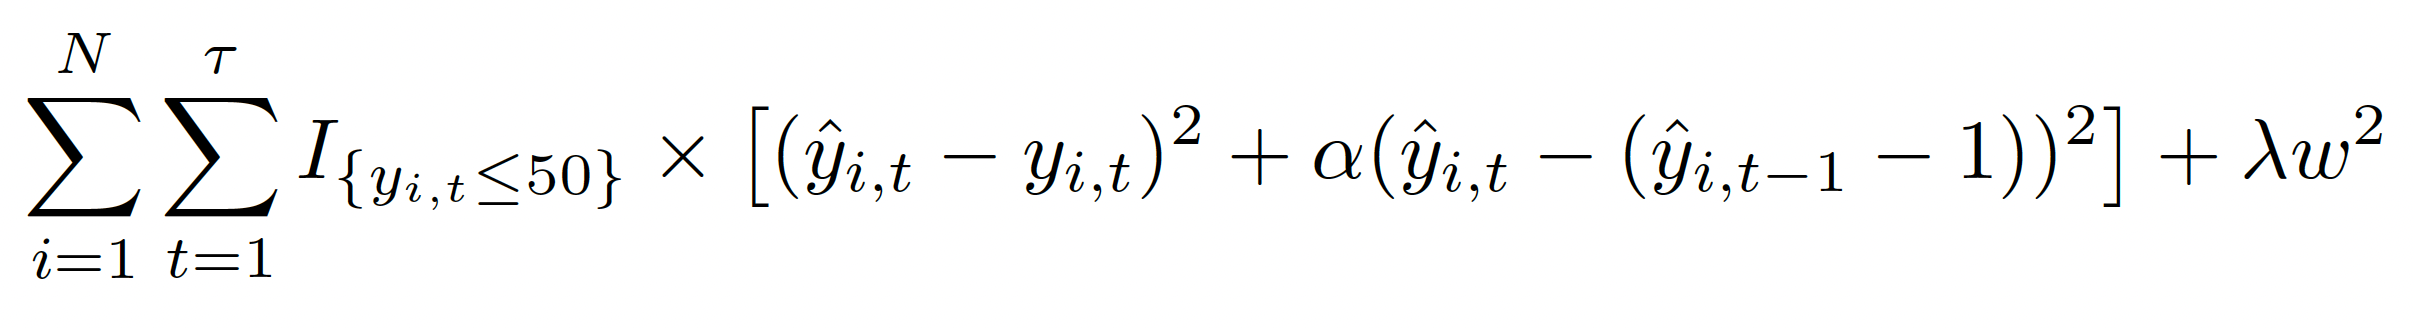

In [31]:
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')

[[ 21.06274378]
 [  0.        ]
 [ -6.29236854]
 [ -6.20591875]
 [ -7.83936925]
 [  0.        ]
 [  9.85612603]
 [ -3.14894744]
 [  4.73181034]
 [ -4.54608577]
 [  4.06259134]
 [-13.83231061]
 [ -5.18353891]
 [  5.24979362]
 [ -2.38762022]
 [  6.43508032]
 [  0.        ]
 [ -5.40938361]
 [  0.        ]
 [  0.        ]
 [  7.02753654]
 [  7.60046672]]
(22, 1)
train set RMSE:103.36051801336599, R2:-1.4302297945491227
valid set RMSE:135.8730363676457, R2:-1.0083073667341376
full data set RMSE:139.30471576912993, R2:-0.9966084417483894


5. Directed MSE

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, models

In [33]:
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# Directed Mean Squared Error를 고려한 Loss function
def directed_mse_loss(y_true, y_pred):
    penalty = tf.where(y_pred > y_true, 13.0, 10.0)
    squared_error = tf.square(y_pred - y_true)
    return tf.reduce_mean(penalty * squared_error, axis=-1)

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

#predictions = lr5.predict(X_train_1_s).flatten()

In [34]:
y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data

78/78 [==============================] - 0s 1ms/step


6. Directed Crucial moments MSE (20)

In [35]:
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data

78/78 [==============================] - 0s 1ms/step


In [36]:
print(y_lr_train_6)
print(y_lr_full_6)

[[19.953037]
 [19.922577]
 [18.614508]
 ...
 [19.274479]
 [19.072533]
 [18.92746 ]]
[[20.570644]
 [19.921331]
 [21.147722]
 ...
 [18.49903 ]
 [16.839413]
 [16.558226]]


Merge!

In [37]:
y_lr_valid_1

array([ 1.68982540e+02,  1.73957603e+02,  1.29389358e+02,  1.33387911e+02,
        1.70110951e+02,  1.36237009e+02,  1.30080434e+02,  1.49229801e+02,
        1.72336200e+02,  1.68014804e+02,  1.77457944e+02,  1.94228615e+02,
        1.60831748e+02,  1.66759252e+02,  1.27113440e+02,  1.63141695e+02,
        1.63981845e+02,  1.34847600e+02,  1.31703211e+02,  1.30194225e+02,
        1.39087340e+02,  1.32010926e+02,  1.42947589e+02,  1.38050393e+02,
        1.08729710e+02,  8.75658693e+01,  6.40661875e+01,  8.94102250e+01,
        5.48898563e+01,  5.31983393e+01,  4.16623136e+01,  4.69602518e+01,
        6.07036561e+01,  4.34562507e+01, -3.62047408e+00, -1.72356307e+01,
       -4.17094605e+01, -1.05405186e+02, -8.20557605e+01,  1.33692905e+02,
        1.08505725e+02,  1.12759351e+02,  1.36809426e+02,  1.27326541e+02,
        1.12501940e+02,  1.05469727e+02,  9.33057616e+01,  1.20837861e+02,
        1.29122597e+02,  1.39586500e+02,  1.22506000e+02,  1.03250857e+02,
        1.13012678e+02,  

concat을 위해 index 제거. 제거하지 않으면 NaN 값들이 데이터프레임에 들어감.

In [38]:
X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

In [39]:
# loss function 별 dataframe들을 list로 저장
y_lr_valid_dfs = [pd.DataFrame(y_lr_valid_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_valid_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_valid_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_valid_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_valid_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_valid_6, columns=['predicted RUL'])]
merged_valid_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_valid_df in enumerate(y_lr_valid_dfs, start=1):
    merged_valid = pd.concat([X_valid_index_names, y_lr_valid_df, y_valid], axis=1)
    merged_valid_dfs.append(merged_valid)
    print(f"Merged Valid DataFrame {i}:\n", merged_valid)

Merged Valid DataFrame 1:
      unit_number  time_cycles  predicted RUL  RUL
0             71           29     168.982540  366
1             71           41     173.957603  354
2             71           43     129.389358  352
3             71           47     133.387911  348
4             71           67     170.110951  328
..           ...          ...            ...  ...
714          100          102      63.921039   43
715          100          103      59.911464   42
716          100          109      57.357252   36
717          100          133      -7.203199   12
718          100          145     -40.675713    0

[719 rows x 4 columns]
Merged Valid DataFrame 2:
      unit_number  time_cycles  predicted RUL  RUL
0             71           29      78.609507  366
1             71           41      87.082706  354
2             71           43      68.441988  352
3             71           47      69.184484  348
4             71           67      83.236362  328
..           ...      

In [40]:
# loss function 별 dataframe들을 list로 저장
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

Merged full DataFrame 1:
       unit_number  time_cycles  predicted RUL  RUL
0               1            8     130.696581  247
1               1           17     156.084322  238
2               1           28     148.974964  227
3               1           29     141.202452  226
4               1           41     134.147958  214
...           ...          ...            ...  ...
2467          100          107      71.333025   37
2468          100          128      32.206952   16
2469          100          132      48.702855   12
2470          100          138      15.330828    6
2471          100          144      -9.498501    0

[2472 rows x 4 columns]
Merged full DataFrame 2:
       unit_number  time_cycles  predicted RUL  RUL
0               1            8      48.294240  247
1               1           17      59.297893  238
2               1           28      54.191179  227
3               1           29      51.862989  226
4               1           41      52.545609  214
...  

# Visualization

**(1) 각 엔진의 online predict value (test data 71~100)**

(X-axis : Time cycles, Y-axis : predicted RUL)

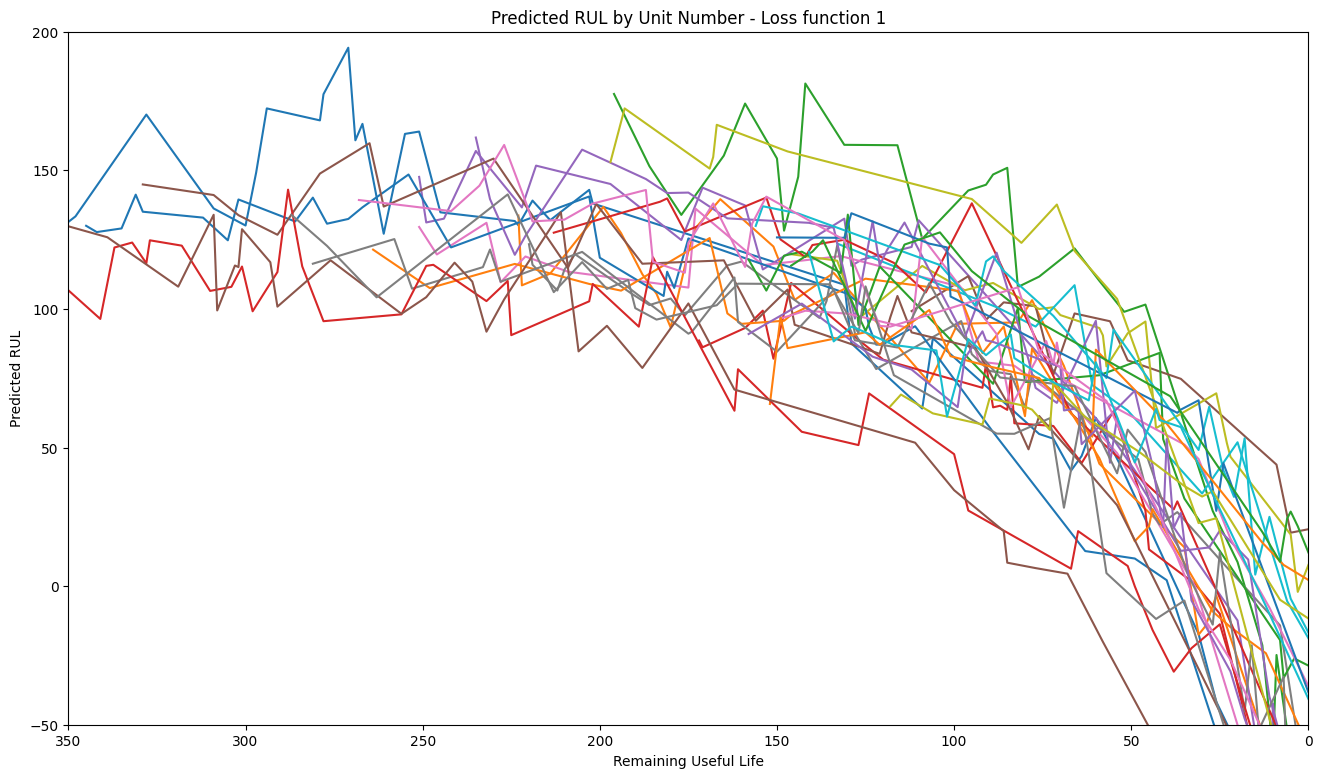

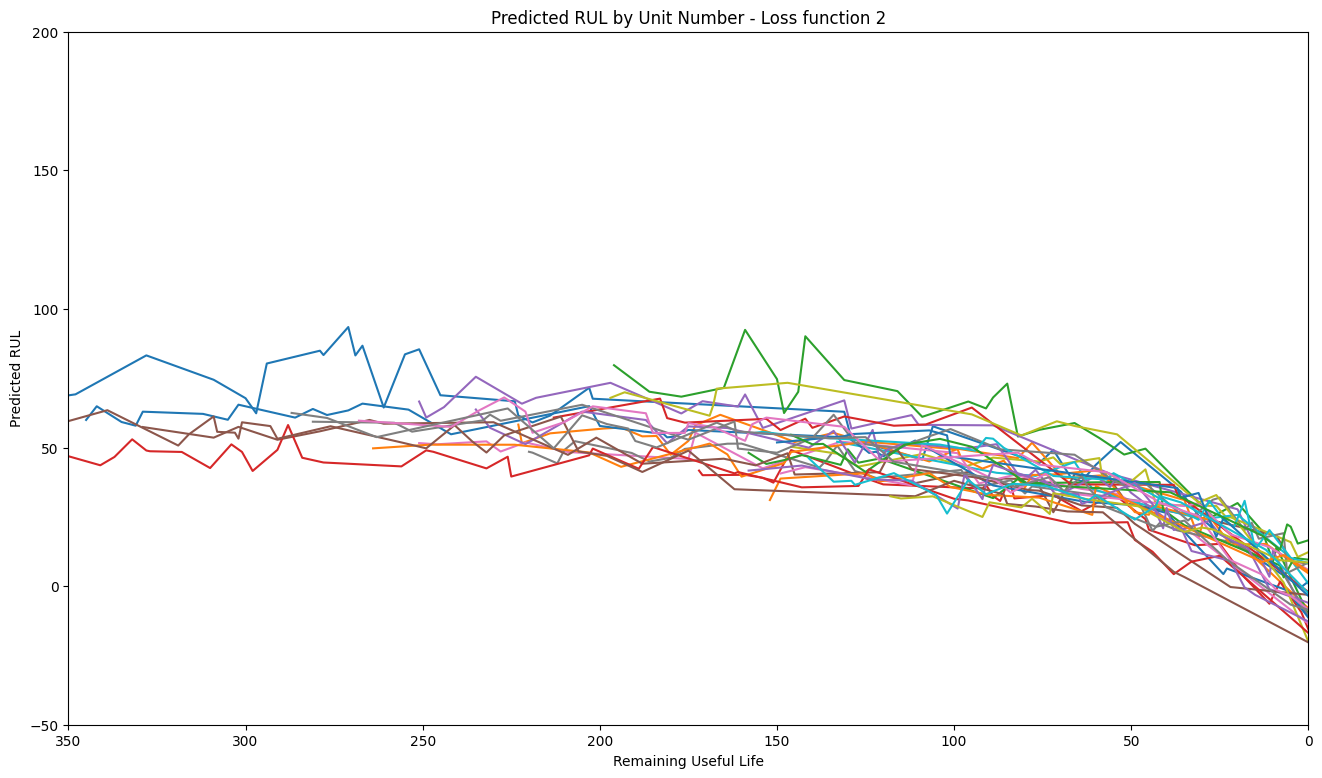

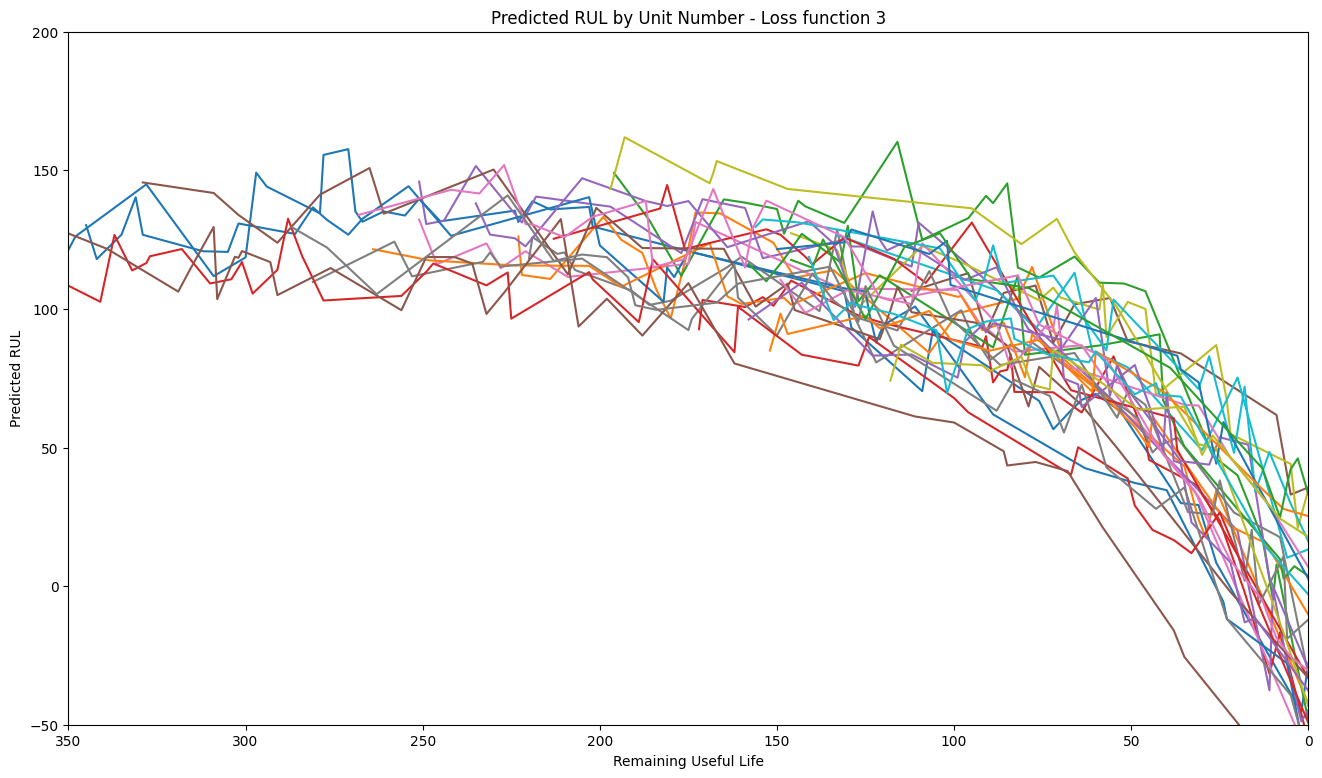

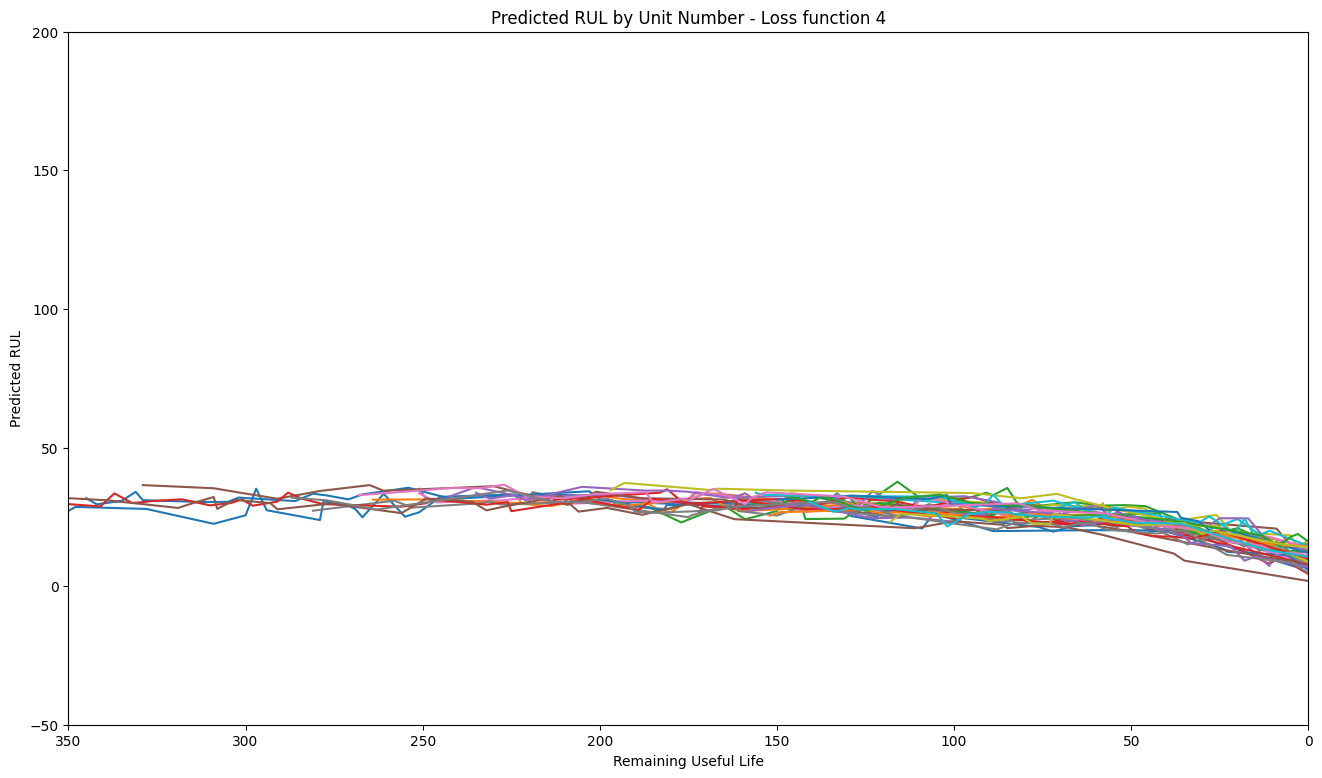

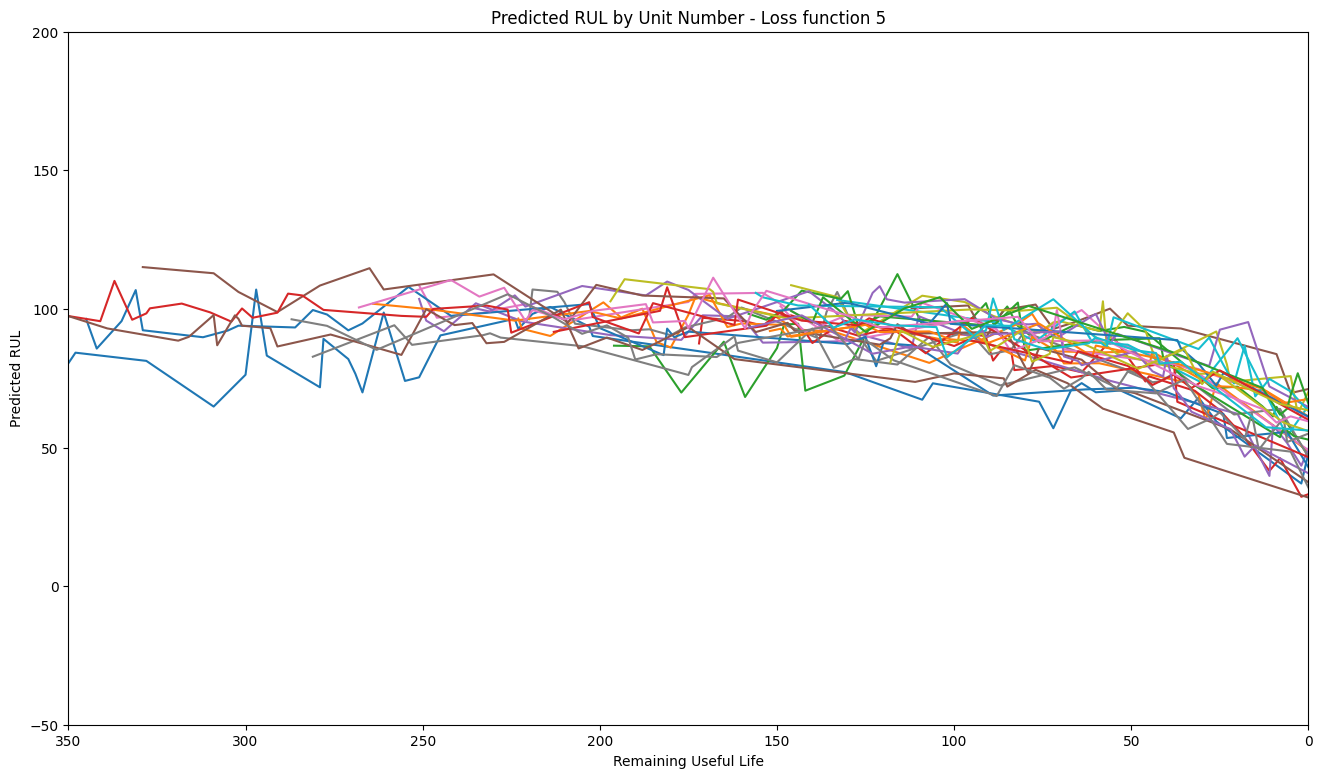

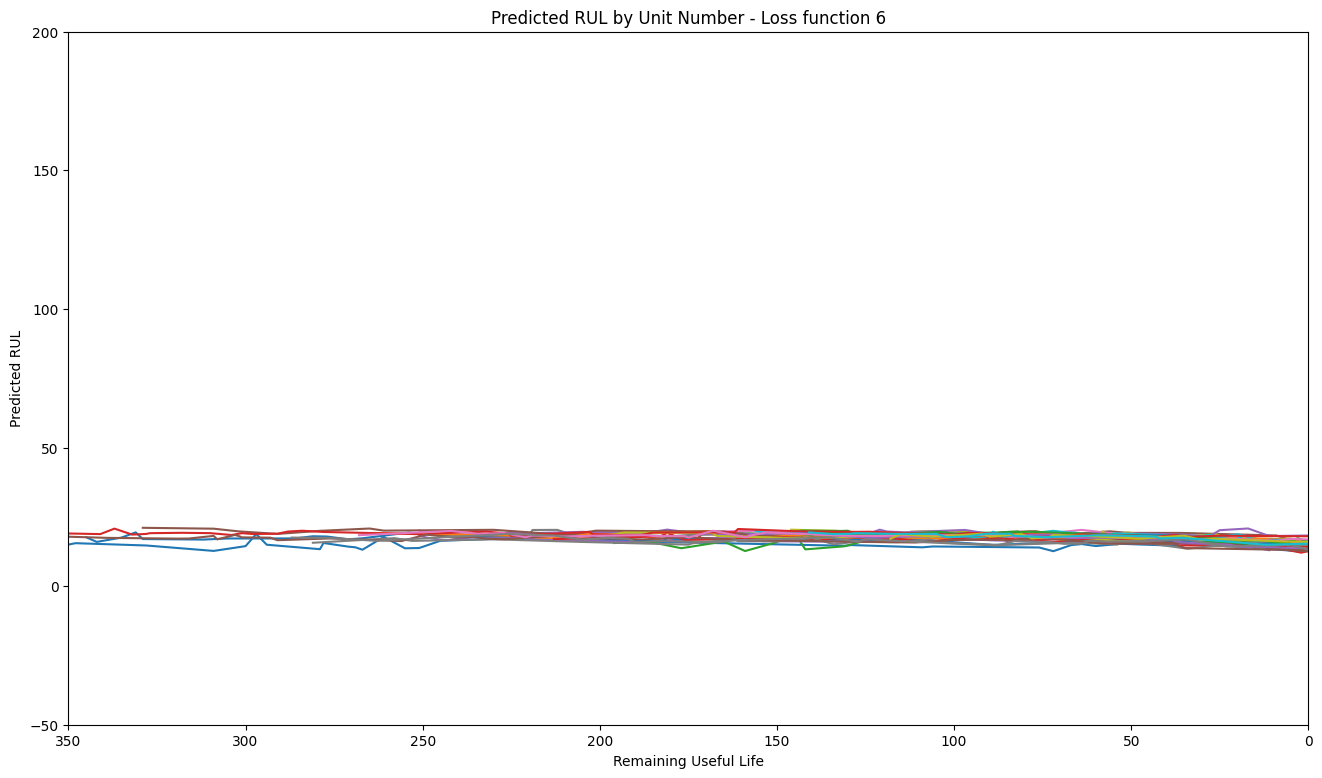

In [41]:
# merged_valid_dfs 리스트에 있는 데이터프레임들에 대해 반복 수행
for i, merged_valid_df in enumerate(merged_valid_dfs, start=1):
    # 데이터프레임에서 unit_number을 기준으로 그룹화
    grouped = merged_valid_df.groupby('unit_number')

    # 그래프를 그릴 subplot을 설정
    fig, ax = plt.subplots(figsize=(16, 9))

    # unit_number 별로 그래프 그리기
    for unit, group in grouped:
        ax.plot(group['RUL'], group['predicted RUL'], label=f'Unit {unit}')

    ax.set_xlabel('Remaining Useful Life')
    ax.set_ylabel('Predicted RUL')
    ax.set_title(f'Predicted RUL by Unit Number - Loss function {i}')
    #ax.legend(loc='upper right')  # 범례 추가

    # 그래프 출력 설정
    plt.xlim(350, 0)  # reverse the x-axis so RUL counts down to zero
    plt.ylim(-50, 200)
    plt.show()

**Threshold, Actual Operation Time**

**Add "Cumulative Operation Time", "Total Cost" Columns**


Cost : Failure (10,000), replace (1000)

**Apply full data set**

In [42]:
# define list of threshold_value
threshold_start = -40        # -40
threshold_end = 90           # 90
threshold_values = list(range(threshold_start, threshold_end + 1))

# Define cost (Tentative Value)
REPLACE_COST = 1000       # replace cost를 크게 늘려도, 반등하는 최저점을 찾을 수 없음 <- Total cost로 해서 상수가 나왔었음. 시간당 cost로 환산하면 커브 그려짐.
FAILURE_COST = 10000

In [43]:
# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()
            """
            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break
            """

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])

**(2) Threshold를 x축으로 두고 분석**

(x-axis : Threshold, y-axis : Number of replace failures)


(x-axis : Threshold, y-axis : Total Cost)

**apply full data**

In [44]:
# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)

DataFrame for merged_valid_df 1:
      Threshold  Number of replace failures  Total Cost  Average usage time
0          -40                          70   31.974070              228.31
1          -39                          70   31.979673              228.27
2          -38                          69   31.595092              228.20
3          -37                          68   31.200701              228.20
4          -36                          67   30.814412              228.14
..         ...                         ...         ...                 ...
126         86                           1    6.226792              175.05
127         87                           1    6.244987              174.54
128         88                           1    6.322873              172.39
129         89                           1    6.343110              171.84
130         90                           1    6.422343              169.72

[131 rows x 4 columns]
DataFrame for merged_valid_df 2:
      Thr

In [45]:
full_nan_counts_and_cost_df_lists = []
full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

**여기부터 average usage time 적용!**

**Scatter plot - Threshold에 따른 replace 실패 횟수와, 엔진 평균 사용시간 - Full data**

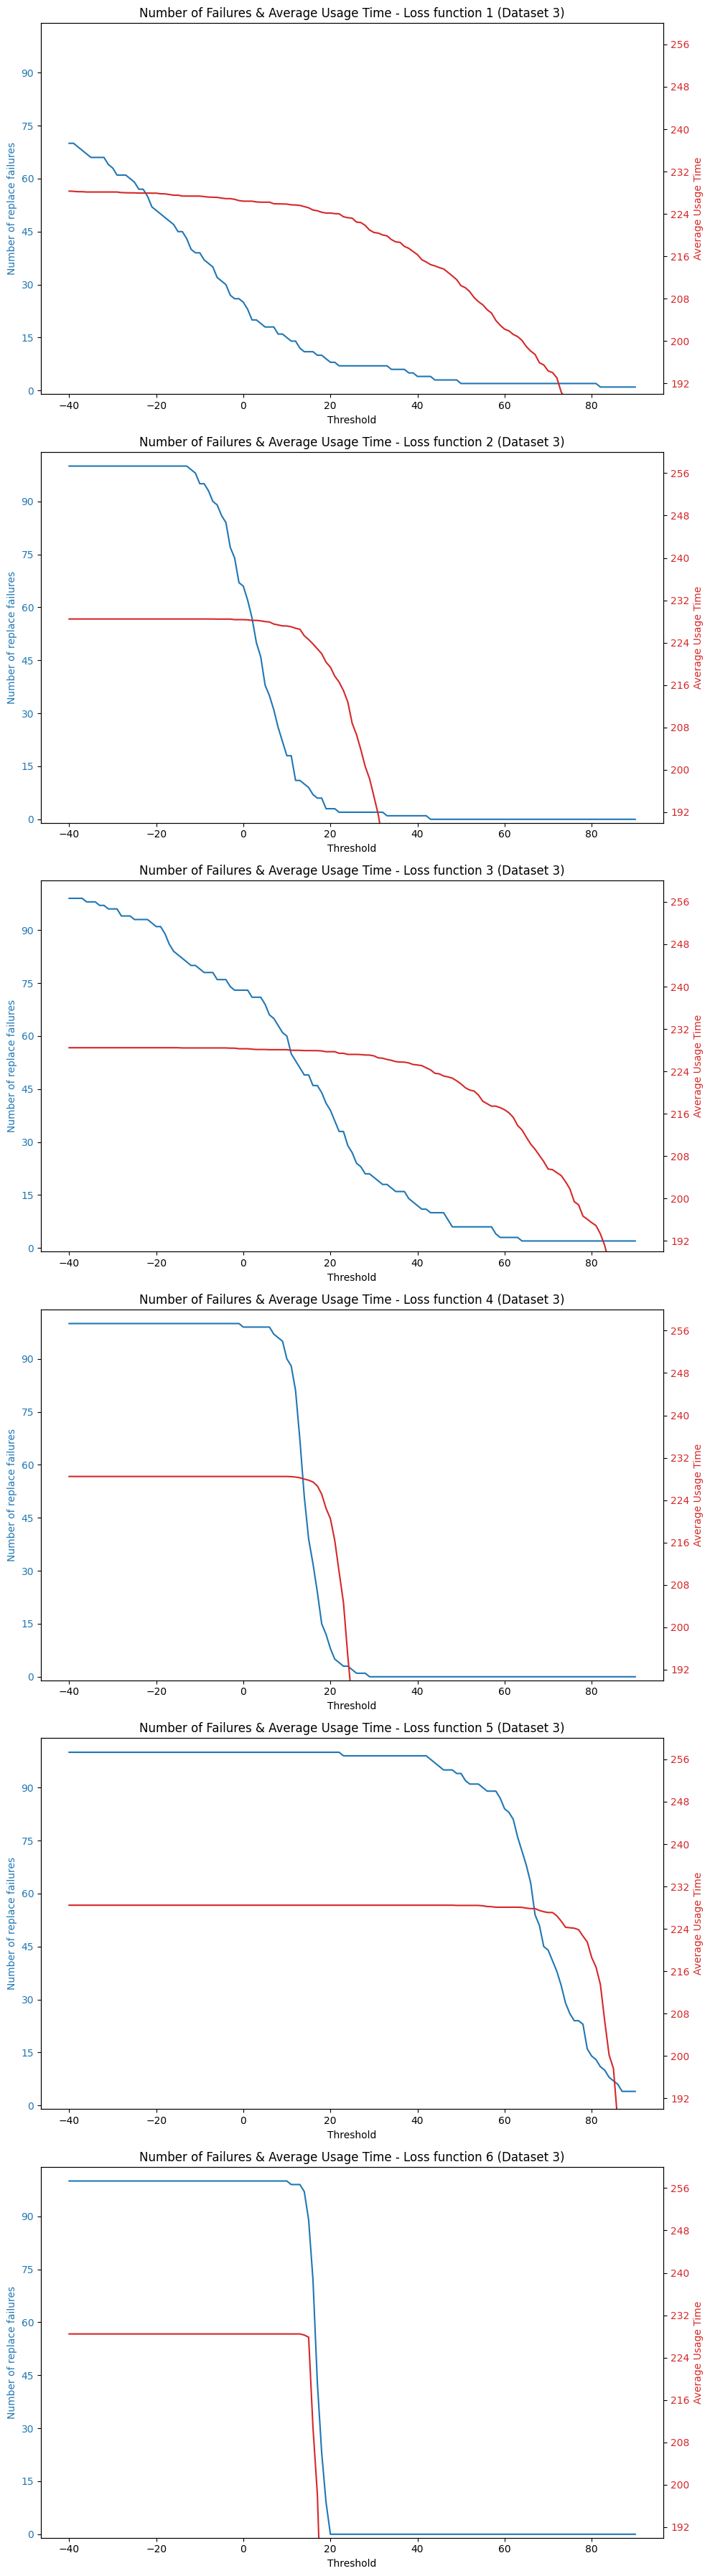

In [46]:
fig, axs = plt.subplots(len(full_nan_counts_and_cost_df_list), 1, figsize=(10, 6*len(full_nan_counts_and_cost_df_list)))

# 데이터프레임들을 저장한 리스트인 nan_counts_and_cost_df_list 내의 각 데이터프레임에 대해 반복 수행
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list, start=1):
    ax1 = axs[i-1]

    # 왼쪽 Y축 그래프 (Number of failures)
    color = 'tab:blue'
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Number of replace failures', color=color)
    ax1.plot(full_nan_counts_and_cost_df['Threshold'], full_nan_counts_and_cost_df['Number of replace failures'], color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))  # 눈금을 정수로 표시
    #ax1.set_ylim(-1,104) ### for Dataset1
    #ax1.set_ylim(-5,270) ### for Dataset2
    ax1.set_ylim(-1,104) ### for Dataset3
    #ax1.set_ylim(-5,260) ### for Dataset4

    # 오른쪽 Y축 그래프 (Average Usage Time)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Average Usage Time', color=color)
    ax2.plot(full_nan_counts_and_cost_df['Threshold'], full_nan_counts_and_cost_df['Average usage time'], color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))  # 눈금을 정수로 표시
    #ax2.set_ylim(150,220) ### for Dataset1
    #ax2.set_ylim(135,220) ### for Dataset2
    ax2.set_ylim(190,260) ### for Dataset3
    #ax2.set_ylim(180,260) ### for Dataset4

    # 그래프 제목 설정
    #ax1.set_title(f'Number of Failures & Average Usage Time - Loss function {i} (Dataset 1)')
    #ax1.set_title(f'Number of Failures & Average Usage Time - Loss function {i} (Dataset 2)')
    ax1.set_title(f'Number of Failures & Average Usage Time - Loss function {i} (Dataset 3)')
    #ax1.set_title(f'Number of Failures & Average Usage Time - Loss function {i} (Dataset 4)')

# 그래프 보이기
plt.tight_layout()  # subplot 간격 조정
plt.show()

Average Cost

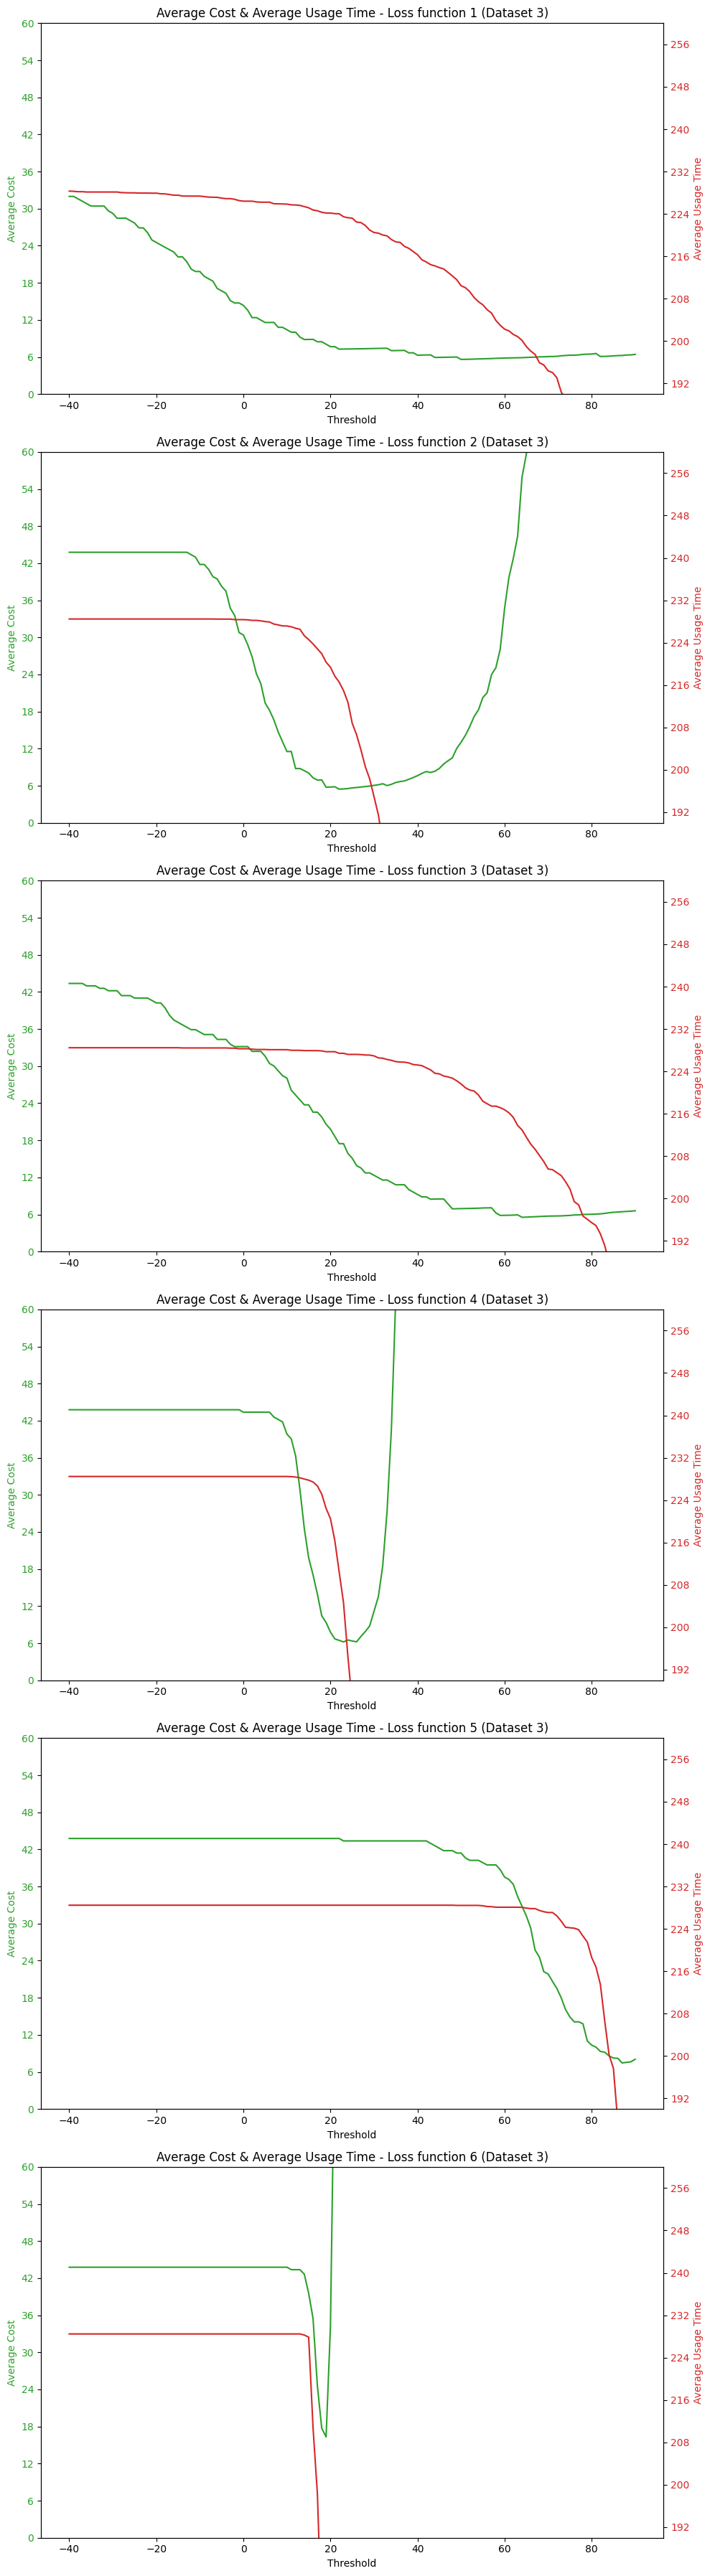

In [47]:
fig, axs = plt.subplots(len(full_nan_counts_and_cost_df_list), 1, figsize=(10, 6*len(full_nan_counts_and_cost_df_list)))

# 데이터프레임들을 저장한 리스트인 nan_counts_and_cost_df_list 내의 각 데이터프레임에 대해 반복 수행
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list, start=1):
    ax1 = axs[i-1]

    # 왼쪽 Y축 그래프 (Average Cost)
    color = 'tab:green'
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Average Cost', color=color)
    ax1.plot(full_nan_counts_and_cost_df['Threshold'], full_nan_counts_and_cost_df['Total Cost'], color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))  # 눈금을 정수로 표시
    #ax1.set_ylim(0,60) ### for dataset1
    #ax1.set_ylim(0,60) ### for dataset2
    ax1.set_ylim(0,60) ### for dataset3
    #ax1.set_ylim(0,60) ### for dataset4
    """
    # 오른쪽 Y축 그래프 (Total Number of Engines Used)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Total Number of Engines Used', color=color)
    ax2.plot(full_nan_counts_and_cost_df['Threshold'], full_nan_counts_and_cost_df['Last index'] + 1, color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))  # 눈금을 정수로 표시
    ax2.set_ylim(75,100)
    """
    # 오른쪽 Y축 그래프 (Average Usage Time)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Average Usage Time', color=color)
    ax2.plot(full_nan_counts_and_cost_df['Threshold'], full_nan_counts_and_cost_df['Average usage time'], color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))  # 눈금을 정수로 표시
    #ax2.set_ylim(150,220) ### for Dataset1
    #ax2.set_ylim(0,220) ### for Dataset2
    ax2.set_ylim(190,260) ### for Dataset3
    #ax2.set_ylim(-0.5,260) ### for Dataset4

    # 그래프 제목 설정
    #ax1.set_title(f'Average Cost & Average Usage Time - Loss function {i} (Dataset 1)')
    #ax1.set_title(f'Average Cost & Average Usage Time - Loss function {i} (Dataset 2)')
    ax1.set_title(f'Average Cost & Average Usage Time - Loss function {i} (Dataset 3)')
    #ax1.set_title(f'Average Cost & Average Usage Time - Loss function {i} (Dataset 4)')

# 그래프 보이기
plt.tight_layout()  # subplot 간격 조정
plt.show()

**Scatter Plot - (Number of Failures vs. Average usage time)**

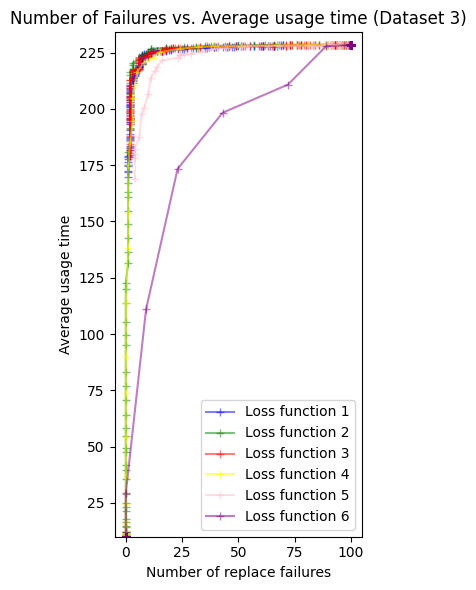

In [59]:
# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(10, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list):

    ax.plot(
        full_nan_counts_and_cost_df['Number of replace failures'],
        full_nan_counts_and_cost_df['Average usage time'],
        '+-',
        label=f'Loss function {i + 1}',
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 2)')
ax.set_title('Number of Failures vs. Average usage time (Dataset 3)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 4)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
#ax.set_ylim(150,190) ### for dataset1
#ax.set_ylim(135,220) ### for dataset2
ax.set_ylim(10,234) ### for dataset3
#ax.set_ylim(180,260) ### for dataset4

ax.set_xlim(-5,105) ### for dataset1,3
#ax.set_xlim(-5,265) ### for dataset2
#ax.set_xlim(-5,255) ### for dataset4

# Set aspect ratio to make the plot square
ax.set_aspect('equal')

# Show the plot
plt.tight_layout()
plt.show()

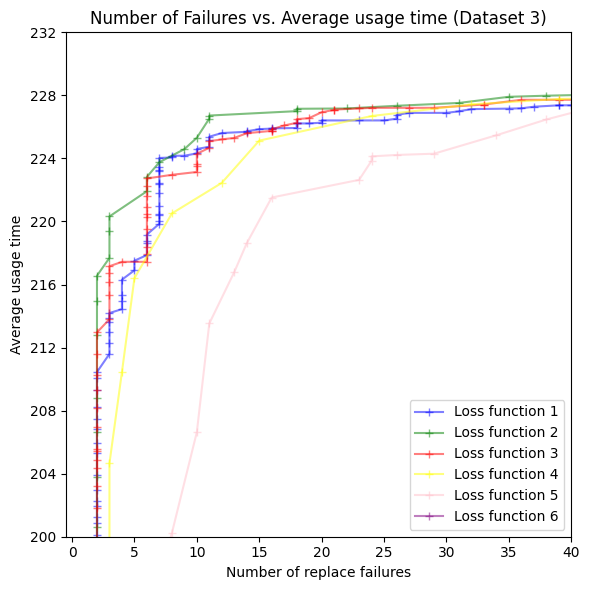

In [61]:
# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(6, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list):
    ax.plot(
        full_nan_counts_and_cost_df['Number of replace failures'],
        full_nan_counts_and_cost_df['Average usage time'], '+-',
        label=f'Loss function {i + 1}',
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 2)')
ax.set_title('Number of Failures vs. Average usage time (Dataset 3)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 4)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

#ax.set_ylim(176,188) ### for dataset1
#ax.set_ylim(172,205) ### for dataset2
ax.set_ylim(200,232) ### for dataset3
#ax.set_ylim(190,237) ### for dataset4
ax.set_xlim(-0.5,40)

# Set aspect ratio to make the plot square
#ax.set_aspect('equal')

# Show the plot
plt.tight_layout()
plt.show()

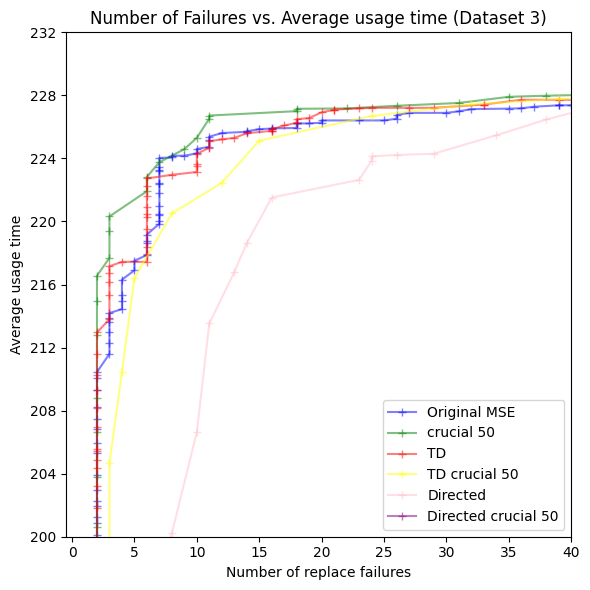

In [62]:
# Create a list of labels
custom_labels = ['Original MSE', 'crucial 50', 'TD', 'TD crucial 50', 'Directed', 'Directed crucial 50']

# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(6, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list):
    ax.plot(
        full_nan_counts_and_cost_df['Number of replace failures'],
        full_nan_counts_and_cost_df['Average usage time'], '+-',
        label=custom_labels[i],  # Use the custom label from the list
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 1)') # for dataset1
ax.set_title('Number of Failures vs. Average usage time (Dataset 3)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

#ax.set_ylim(176,188) ### for dataset1

ax.set_ylim(200,232) ### for dataset3

ax.set_xlim(-0.5,40)


# Show the plot
plt.tight_layout()
plt.show()

# 반복 시작 (나중에 최적화)

2번 샘플에 대해 코드 실행 (계속 반복)

In [63]:
train = sampled_data_list[1][0].copy()
valid = sampled_data_list[1][1].copy()
full_data = sampled_data_list[1][2].copy()

In [64]:
train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

In [65]:
drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

In [66]:
X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

In [67]:
# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


train set RMSE:38.01130016569505, R2:0.672701052225646
valid set RMSE:82.74512492401749, R2:0.34882186591157305
full data set RMSE:68.82912247150193, R2:0.5008717265334524
train set RMSE:87.01241587514394, R2:-0.715069064089026
valid set RMSE:127.29417701755885, R2:-0.5411043710342174
full data set RMSE:119.35490079933847, R2:-0.5008877693631186
[[139.05419449]
 [  0.        ]
 [-22.33424306]
 [-29.93753533]
 [-39.4026656 ]
 [  0.        ]
 [ 48.69867802]
 [-17.76809069]
 [-16.11307352]
 [-47.33304043]
 [ -5.64884691]
 [-60.11508005]
 [-25.03690689]
 [-19.77304368]
 [-34.85877671]
 [ 31.67123432]
 [  0.        ]
 [-30.42854945]
 [  0.        ]
 [  0.        ]
 [ 40.87698998]
 [ 48.46370621]]
(22, 1)
train set RMSE:40.664952975472076, R2:0.6254069560764848
valid set RMSE:90.44495220689012, R2:0.2219927497049512
full data set RMSE:75.78121204715923, R2:0.39495064752266906
[[ 20.88877134]
 [  0.        ]
 [ -8.70075043]
 [ -4.94534526]
 [ -8.40919008]
 [  0.        ]
 [ 11.69342139]
 [ -3

In [68]:
X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])

Merged full DataFrame 1:
       unit_number  time_cycles  predicted RUL  RUL
0               1           28     173.363181  226
1               1           32     168.874426  222
2               1           39     161.569842  215
3               1           42     155.505502  212
4               1           44     156.942498  210
...           ...          ...            ...  ...
2467          100           98     115.935254   54
2468          100          125      78.995883   27
2469          100          135      63.627109   17
2470          100          150      19.612894    2
2471          100          152      26.701380    0

[2472 rows x 4 columns]
Merged full DataFrame 2:
       unit_number  time_cycles  predicted RUL  RUL
0               1           28      51.013836  226
1               1           32      55.307219  222
2               1           39      58.319331  215
3               1           42      55.908516  212
4               1           44      51.572395  210
...  

In [69]:
# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)

DataFrame for merged_valid_df 1:
      Threshold  Number of replace failures  Total Cost  Average usage time
0          -40                          96   42.158664              228.66
1          -39                          96   42.158664              228.66
2          -38                          95   41.765066              228.66
3          -37                          94   41.371469              228.66
4          -36                          92   40.584274              228.66
..         ...                         ...         ...                 ...
126         86                           3    6.191498              205.12
127         87                           3    6.212092              204.44
128         88                           2    5.797671              203.53
129         89                           2    5.820549              202.73
130         90                           2    5.856661              201.48

[131 rows x 4 columns]
DataFrame for merged_valid_df 2:
      Thr

In [70]:
full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

3번째 반복

In [71]:
train = sampled_data_list[2][0].copy()
valid = sampled_data_list[2][1].copy()
full_data = sampled_data_list[2][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:37.510973162439946, R2:0.6762856742935316
valid set RMSE:86.78916501104159, R2:0.20657856726292467
full data set RMSE:71.3526389761171, R2:0.487379550210265
train set RMSE:86.55386807185477, R2:-0.7235275059189803
valid set RMSE:129.10953160012673, R2:-0.7558585181299948
full data set RMSE:125.06554097394054, R2:-0.5748934584826195
[[ 1.43655336e+02]
 [ 0.00000000e+00]
 [-2.74686096e+01]
 [-2.42945464e+01]
 [-4.14803614e+01]
 [ 0.00000000e+00]
 [ 5.08674107e+01]
 [-2.74506291e+01]
 [-9.66980866e+00]
 [-3.71510569e+01]
 [-7.08230098e-02]
 [-7.19653216e+01]
 [-2.55235285e+01]
 [-1.26362616e+01]
 [-2.10196532e+01]
 [ 2.28641583e+01]
 [ 0.00000000e+00]
 [-3.58609838e+01]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 3.79723348e+01]
 [ 3.17921741e+01]]
(22, 1)
train set RMSE:40.19756668162689, R2:0.6282553003626294
valid set RMSE:86.46489339511966, R2:0.2124964350752072
full data set RMSE:77.03082231010433, R2:0.4025453919068718
[[ 20.59023743]
 [  0.        ]
 [ -6.64913686]
 [ -

4번째 반복

In [72]:
train = sampled_data_list[3][0].copy()
valid = sampled_data_list[3][1].copy()
full_data = sampled_data_list[3][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:37.359017163313126, R2:0.6886045994432854
valid set RMSE:86.44664069669348, R2:0.22307861275680252
full data set RMSE:72.86394556740666, R2:0.4671991862073054
train set RMSE:89.23152872932135, R2:-0.7764704009554981
valid set RMSE:121.55800650628728, R2:-0.5362007499825454
full data set RMSE:126.09758864050157, R2:-0.5957067193543917
[[142.11203392]
 [  0.        ]
 [-28.7385136 ]
 [-22.45535014]
 [-42.7106277 ]
 [  0.        ]
 [ 46.53094491]
 [ -9.38784558]
 [-13.04850957]
 [-44.41415133]
 [-19.35631327]
 [-57.37939705]
 [-25.74082938]
 [-23.62520752]
 [-25.9123042 ]
 [ 24.34739753]
 [  0.        ]
 [-31.19352912]
 [  0.        ]
 [  0.        ]
 [ 39.988779  ]
 [ 33.78387389]]
(22, 1)
train set RMSE:40.32047860379461, R2:0.6372790285150858
valid set RMSE:85.56492222369366, R2:0.23884631521593325
full data set RMSE:79.13320915922439, R2:0.3715697712104543
[[ 18.29320633]
 [  0.        ]
 [ -4.0180145 ]
 [ -3.92714572]
 [ -9.64321727]
 [  0.        ]
 [ 10.29282599]
 [ 

5번째 반복

In [73]:
train = sampled_data_list[4][0].copy()
valid = sampled_data_list[4][1].copy()
full_data = sampled_data_list[4][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:35.54946878085585, R2:0.7113284894339411
valid set RMSE:79.8803783932261, R2:0.2831599141995693
full data set RMSE:75.0179156166, R2:0.4425927166871402
train set RMSE:84.52806623922575, R2:-0.6320729292940888
valid set RMSE:117.3213042745595, R2:-0.5463073532092293
full data set RMSE:125.73558268284928, R2:-0.5658820670147009
[[146.05385584]
 [  0.        ]
 [-24.14271415]
 [-26.06523077]
 [-45.97757614]
 [  0.        ]
 [ 58.64698832]
 [-25.30690365]
 [-18.94689677]
 [-33.73098399]
 [ -1.06245884]
 [-68.95623862]
 [-29.48931948]
 [-22.20658003]
 [-27.78470637]
 [ 17.20817678]
 [  0.        ]
 [-27.2801364 ]
 [  0.        ]
 [  0.        ]
 [ 35.16844633]
 [ 41.86171482]]
(22, 1)
train set RMSE:38.62947581590252, R2:0.659140561686917
valid set RMSE:79.97155528660831, R2:0.2815225520713339
full data set RMSE:79.66773280187715, R2:0.3713519551253114
[[ 21.40993946]
 [  0.        ]
 [ -4.08075398]
 [ -4.53071093]
 [ -9.61446818]
 [  0.        ]
 [ 12.5422498 ]
 [ -4.9553574

6번째 반복

In [74]:
train = sampled_data_list[5][0].copy()
valid = sampled_data_list[5][1].copy()
full_data = sampled_data_list[5][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.93454534966113, R2:0.6889426785003618
valid set RMSE:81.59788889989778, R2:0.2789990239307576
full data set RMSE:73.63583540447837, R2:0.4737714981599286
train set RMSE:87.52724965769454, R2:-0.7468735825339263
valid set RMSE:120.37409595846907, R2:-0.5690763767958442
full data set RMSE:124.54151883022101, R2:-0.5053041046906226
[[139.93208354]
 [  0.        ]
 [-27.8289345 ]
 [-22.00638799]
 [-44.98063212]
 [  0.        ]
 [ 42.88697072]
 [-21.46919317]
 [-12.23988276]
 [-35.77800631]
 [-26.90519772]
 [-65.35326333]
 [-19.66923777]
 [-19.54386463]
 [-20.29577226]
 [ 29.02809089]
 [  0.        ]
 [-37.09069645]
 [  0.        ]
 [  0.        ]
 [ 50.19187858]
 [ 36.97795193]]
(22, 1)
train set RMSE:39.679019633939625, R2:0.6409980728987773
valid set RMSE:80.74553389735246, R2:0.2939832121496999
full data set RMSE:79.85272605402487, R2:0.3811642083538602
[[ 19.69889176]
 [  0.        ]
 [ -2.83842221]
 [ -5.74036444]
 [ -9.22622732]
 [  0.        ]
 [  8.75536115]
 [ -2

7번째 반복

In [75]:
train = sampled_data_list[6][0].copy()
valid = sampled_data_list[6][1].copy()
full_data = sampled_data_list[6][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:35.61312665620815, R2:0.7207356167517127
valid set RMSE:89.4706749250119, R2:0.12165507106456175
full data set RMSE:71.57495867889911, R2:0.4785904852750862
train set RMSE:84.19227072036765, R2:-0.5607731581620754
valid set RMSE:126.14294341567293, R2:-0.745941116022024
full data set RMSE:121.63371744833091, R2:-0.5057910111212114
[[135.51996581]
 [  0.        ]
 [-26.98295601]
 [-19.68662636]
 [-47.65903749]
 [  0.        ]
 [ 65.45088542]
 [-10.53574287]
 [-26.05351549]
 [-46.65091897]
 [-29.62762882]
 [-57.51080429]
 [-19.55971022]
 [-25.75130182]
 [-30.16167322]
 [ 15.28529313]
 [  0.        ]
 [-25.13139798]
 [  0.        ]
 [  0.        ]
 [ 43.70526511]
 [ 41.72606945]]
(22, 1)
train set RMSE:38.48472311086818, R2:0.6738840244219471
valid set RMSE:85.31908356554382, R2:0.20127728570312986
full data set RMSE:76.96379689918223, R2:0.3971216200838198
[[ 20.77224641]
 [  0.        ]
 [ -5.86513608]
 [ -5.59685165]
 [ -8.82865238]
 [  0.        ]
 [ 13.47582565]
 [ -3.

8번째 반복

In [76]:
train = sampled_data_list[7][0].copy()
valid = sampled_data_list[7][1].copy()
full_data = sampled_data_list[7][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.25532754914006, R2:0.7054968899744659
valid set RMSE:83.45296319657517, R2:0.28718204636304634
full data set RMSE:71.30167327092921, R2:0.48529955747560893
train set RMSE:87.26019741836868, R2:-0.7059983295015777
valid set RMSE:123.86231517287878, R2:-0.5702669589706868
full data set RMSE:121.99694580352092, R2:-0.5067909898093879
[[139.69331912]
 [  0.        ]
 [-25.21372118]
 [-33.40572589]
 [-53.87873216]
 [  0.        ]
 [ 39.47713568]
 [ -8.29258638]
 [ -7.72307579]
 [-42.43470653]
 [-38.55624328]
 [-55.56518543]
 [-23.53690648]
 [-10.18628964]
 [-24.89204306]
 [ 27.0291346 ]
 [  0.        ]
 [-35.3052988 ]
 [  0.        ]
 [  0.        ]
 [ 44.98486486]
 [ 37.09187854]]
(22, 1)
train set RMSE:39.09152158476281, R2:0.6576176493048209
valid set RMSE:84.22650997106055, R2:0.27390621931010317
full data set RMSE:77.09852689479472, R2:0.39820682449312084
[[ 20.88002269]
 [  0.        ]
 [ -3.0694326 ]
 [ -3.19041149]
 [-11.42985401]
 [  0.        ]
 [  9.56746085]
 [

9번째 반복

In [77]:
train = sampled_data_list[8][0].copy()
valid = sampled_data_list[8][1].copy()
full_data = sampled_data_list[8][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:37.693424436722374, R2:0.6783914266468323
valid set RMSE:78.92690019668099, R2:0.3515138010246559
full data set RMSE:71.26001054529026, R2:0.47871413689804143
train set RMSE:89.41033994361011, R2:-0.8095555521036752
valid set RMSE:122.52096964288518, R2:-0.5626851865699796
full data set RMSE:122.09392867150113, R2:-0.5302849943218642
[[149.20494428]
 [  0.        ]
 [-27.68476052]
 [-34.9905668 ]
 [-48.06933614]
 [  0.        ]
 [ 55.57056102]
 [-17.18259117]
 [-14.32381607]
 [-36.49636859]
 [ -4.01840049]
 [-60.81814412]
 [-31.66598555]
 [-16.70693549]
 [-29.05070258]
 [ 22.12196747]
 [  0.        ]
 [-35.66949725]
 [  0.        ]
 [  0.        ]
 [ 41.48965829]
 [ 43.73230594]]
(22, 1)
train set RMSE:40.53337614520235, R2:0.6281035901658423
valid set RMSE:83.30896495919951, R2:0.2775062035736833
full data set RMSE:76.24178246703015, R2:0.40328045207329255
[[ 20.25448242]
 [  0.        ]
 [ -3.50860355]
 [ -5.20405841]
 [ -9.1544218 ]
 [  0.        ]
 [ 11.6341715 ]
 [ 

10번째 반복

In [78]:
train = sampled_data_list[9][0].copy()
valid = sampled_data_list[9][1].copy()
full_data = sampled_data_list[9][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.45234777380308, R2:0.6935219340604262
valid set RMSE:87.1384503670022, R2:0.20565962307220942
full data set RMSE:73.45610558968254, R2:0.4570067805018806
train set RMSE:83.66235554023118, R2:-0.6143903932209689
valid set RMSE:118.6955521631009, R2:-0.47385875000459143
full data set RMSE:118.53494421337389, R2:-0.413941385722324
[[138.73607975]
 [  0.        ]
 [-21.16815509]
 [-29.31169726]
 [-44.6943262 ]
 [  0.        ]
 [ 46.47401623]
 [-12.47538327]
 [-13.78975451]
 [-47.44679719]
 [-22.91640593]
 [-63.71476889]
 [-21.67006736]
 [ -9.54867277]
 [-29.00808759]
 [ 25.08100531]
 [  0.        ]
 [-32.99176697]
 [  0.        ]
 [  0.        ]
 [ 42.45074348]
 [ 36.4868979 ]]
(22, 1)
train set RMSE:39.482930029711255, R2:0.640443506249756
valid set RMSE:83.43665885190639, R2:0.27171597533433345
full data set RMSE:78.93302799750755, R2:0.3730164683723126
[[ 20.76779065]
 [  0.        ]
 [ -6.68094507]
 [ -5.33151247]
 [-10.81020364]
 [  0.        ]
 [ 10.76983218]
 [ -3.

11

In [79]:
train = sampled_data_list[10][0].copy()
valid = sampled_data_list[10][1].copy()
full_data = sampled_data_list[10][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:37.56074163722318, R2:0.6809269967499612
valid set RMSE:76.84567642641792, R2:0.3135084104759527
full data set RMSE:71.59589665978842, R2:0.4754188947553758
train set RMSE:89.06237500086651, R2:-0.7939498030271435
valid set RMSE:115.06161271268614, R2:-0.539066052654799
full data set RMSE:121.18682453514897, R2:-0.5029591969780418
[[135.01692357]
 [  0.        ]
 [-28.54430512]
 [-30.90164825]
 [-42.52517777]
 [  0.        ]
 [ 52.58890522]
 [-24.03603416]
 [-12.89764632]
 [-53.2198344 ]
 [  3.48895664]
 [-67.37818697]
 [-31.47834439]
 [-14.43228843]
 [-30.97070908]
 [ 26.9732013 ]
 [  0.        ]
 [-28.45400376]
 [  0.        ]
 [  0.        ]
 [ 46.66478067]
 [ 43.04116608]]
(22, 1)
train set RMSE:40.27776581211798, R2:0.6330959654629394
valid set RMSE:75.69359825724834, R2:0.3339380154661261
full data set RMSE:78.41268846966895, R2:0.37077051127587324
[[ 18.62924884]
 [  0.        ]
 [ -4.75977284]
 [ -3.26212709]
 [-10.47143849]
 [  0.        ]
 [ 10.39563993]
 [ -3.

In [80]:
train = sampled_data_list[11][0].copy()
valid = sampled_data_list[11][1].copy()
full_data = sampled_data_list[11][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:37.207190534467614, R2:0.6914126305955579
valid set RMSE:74.79476404217377, R2:0.38263478079691615
full data set RMSE:72.92809082422615, R2:0.45917105559236615
train set RMSE:84.32604856389793, R2:-0.585067969958927
valid set RMSE:111.76798511200585, R2:-0.3785883671860284
full data set RMSE:121.29022481937116, R2:-0.49596640184079366
[[144.87214897]
 [  0.        ]
 [-25.65480954]
 [-26.94121759]
 [-47.97551737]
 [  0.        ]
 [ 35.7796698 ]
 [-17.12782569]
 [-11.22677018]
 [-42.41329365]
 [-27.13509825]
 [-60.70524869]
 [-23.33621862]
 [-12.72877438]
 [-27.00986604]
 [ 20.13104914]
 [  0.        ]
 [-24.23831104]
 [  0.        ]
 [  0.        ]
 [ 45.14795023]
 [ 42.34113214]]
(22, 1)
train set RMSE:39.958049825421206, R2:0.6440959271823967
valid set RMSE:73.84734969845735, R2:0.39817587503842466
full data set RMSE:78.70365502593363, R2:0.37011677720351277
[[ 19.70222724]
 [  0.        ]
 [ -4.7564619 ]
 [ -5.0654812 ]
 [ -9.70569843]
 [  0.        ]
 [ 11.89130586]


In [81]:
train = sampled_data_list[12][0].copy()
valid = sampled_data_list[12][1].copy()
full_data = sampled_data_list[12][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.87110264469819, R2:0.6905671043170678
valid set RMSE:84.18685423130749, R2:0.27919128950655936
full data set RMSE:73.95558672788164, R2:0.4153335565708077
train set RMSE:88.11787262573381, R2:-0.7673486716271976
valid set RMSE:123.1105973808466, R2:-0.5414247926976157
full data set RMSE:121.93492027531039, R2:-0.58936041437021
[[141.92316328]
 [  0.        ]
 [-26.68699448]
 [-19.55982096]
 [-36.66960784]
 [  0.        ]
 [ 50.16344831]
 [-19.71296337]
 [ -6.29816156]
 [-37.27673329]
 [-25.66282946]
 [-63.22290369]
 [-29.83716013]
 [-21.27624935]
 [-29.93980341]
 [ 14.85192857]
 [  0.        ]
 [-30.88061614]
 [  0.        ]
 [  0.        ]
 [ 47.98068581]
 [ 38.80826627]]
(22, 1)
train set RMSE:39.4979055760353, R2:0.6449067924723865
valid set RMSE:83.51857691665661, R2:0.2905894642016973
full data set RMSE:78.5145841158897, R2:0.3410281482576747
[[ 21.8262897 ]
 [  0.        ]
 [ -4.77671564]
 [ -4.54047759]
 [ -6.9031577 ]
 [  0.        ]
 [ 10.4123309 ]
 [ -2.2543

In [82]:
train = sampled_data_list[13][0].copy()
valid = sampled_data_list[13][1].copy()
full_data = sampled_data_list[13][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:38.557698436222424, R2:0.6589368619081833
valid set RMSE:94.53316377250248, R2:0.08267025241866233
full data set RMSE:69.46052663589602, R2:0.48610145606568866
train set RMSE:89.70267446686609, R2:-0.8459645740815711
valid set RMSE:129.35515216570022, R2:-0.7176099764521582
full data set RMSE:121.50392120307228, R2:-0.5724680547298884
[[129.58926085]
 [  0.        ]
 [-29.39219036]
 [-22.65952983]
 [-45.17777945]
 [  0.        ]
 [ 54.75253879]
 [-15.40679728]
 [-11.24613133]
 [-38.08751534]
 [-16.76990501]
 [-63.98834244]
 [-21.19885053]
 [-16.12299777]
 [-24.32723366]
 [ 23.00836949]
 [  0.        ]
 [-26.62529355]
 [  0.        ]
 [  0.        ]
 [ 42.4524415 ]
 [ 37.15256285]]
(22, 1)
train set RMSE:41.324167967969196, R2:0.60823934673443
valid set RMSE:91.03858014829325, R2:0.14923807908117737
full data set RMSE:78.71872493160106, R2:0.33997962052645436
[[ 16.87871739]
 [  0.        ]
 [ -2.72084106]
 [ -4.66371111]
 [ -7.03215073]
 [  0.        ]
 [ 12.4688899 ]
 [

In [83]:
train = sampled_data_list[14][0].copy()
valid = sampled_data_list[14][1].copy()
full_data = sampled_data_list[14][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:38.73012446678372, R2:0.670414787429369
valid set RMSE:84.56390832383354, R2:0.1278014678340813
full data set RMSE:74.4914679736654, R2:0.43467379313036036
train set RMSE:93.92044471763218, R2:-0.9381626198021449
valid set RMSE:117.21247716174184, R2:-0.6756871789927676
full data set RMSE:128.51599177539603, R2:-0.68267559950145
[[134.06740288]
 [  0.        ]
 [-25.62383037]
 [-25.69718553]
 [-40.24490964]
 [  0.        ]
 [ 55.15083165]
 [-16.71140284]
 [-13.9505154 ]
 [-35.28700787]
 [-31.57215552]
 [-59.91208117]
 [-19.90130922]
 [-19.17448098]
 [-31.22019138]
 [ 13.02213544]
 [  0.        ]
 [-29.63313537]
 [  0.        ]
 [  0.        ]
 [ 44.57672908]
 [ 43.63872006]]
(22, 1)
train set RMSE:41.298913934498884, R2:0.6252452083815445
valid set RMSE:76.40012091348319, R2:0.28807646565808986
full data set RMSE:77.8658722907944, R2:0.3822960775061378
[[ 19.28215172]
 [  0.        ]
 [ -1.23619387]
 [ -3.33861751]
 [ -7.98967913]
 [  0.        ]
 [  9.5647517 ]
 [ -3.19

In [84]:
train = sampled_data_list[15][0].copy()
valid = sampled_data_list[15][1].copy()
full_data = sampled_data_list[15][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.09321593115869, R2:0.7093189834418889
valid set RMSE:89.3134083795832, R2:0.25108910941444473
full data set RMSE:69.76795194689204, R2:0.46870060030007343
train set RMSE:85.57242278005629, R2:-0.6339289482661099
valid set RMSE:126.83506518238083, R2:-0.5103426710216354
full data set RMSE:119.00243472224265, R2:-0.5457493419988544
[[139.58012434]
 [  0.        ]
 [-25.87090076]
 [-20.37506968]
 [-54.25497484]
 [  0.        ]
 [ 52.9704965 ]
 [-27.24590905]
 [-11.77621166]
 [-33.34974286]
 [  3.20786652]
 [-65.98869899]
 [-33.82655954]
 [-11.41132861]
 [-31.24240657]
 [ 22.72562844]
 [  0.        ]
 [-36.68786859]
 [  0.        ]
 [  0.        ]
 [ 43.32340757]
 [ 42.39616336]]
(22, 1)
train set RMSE:39.15615822034279, R2:0.6578900855990659
valid set RMSE:88.90786129369374, R2:0.25787485601841087
full data set RMSE:74.12617720816908, R2:0.4002495485704549
[[ 19.30891051]
 [  0.        ]
 [ -6.16529857]
 [ -3.19814892]
 [ -9.46347758]
 [  0.        ]
 [ 13.0451068 ]
 [ -

In [85]:
train = sampled_data_list[16][0].copy()
valid = sampled_data_list[16][1].copy()
full_data = sampled_data_list[16][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.60117991751747, R2:0.7024921923950553
valid set RMSE:82.62673357616438, R2:0.24683699429027184
full data set RMSE:70.97443281285432, R2:0.45984839303130765
train set RMSE:86.19051676829113, R2:-0.6497842936154983
valid set RMSE:122.0245263228719, R2:-0.6426387816249548
full data set RMSE:120.04328406897548, R2:-0.5452101330287462
[[137.56321833]
 [  0.        ]
 [-34.0876073 ]
 [-23.78754623]
 [-45.80015338]
 [  0.        ]
 [ 52.3490438 ]
 [-20.33766516]
 [-17.873778  ]
 [-40.91841137]
 [ 11.88869237]
 [-67.0291133 ]
 [-27.35993726]
 [-17.62697443]
 [-23.33212249]
 [ 30.35349523]
 [  0.        ]
 [-42.15253699]
 [  0.        ]
 [  0.        ]
 [ 40.48111462]
 [ 37.56150259]]
(22, 1)
train set RMSE:39.470588526091994, R2:0.654016490639206
valid set RMSE:80.33797992565884, R2:0.2879842085976002
full data set RMSE:76.299512567409, R2:0.375754617861368
[[ 20.75343426]
 [  0.        ]
 [ -3.520358  ]
 [ -5.41940243]
 [ -8.31971037]
 [  0.        ]
 [  9.30756993]
 [ -4.13

In [86]:
train = sampled_data_list[17][0].copy()
valid = sampled_data_list[17][1].copy()
full_data = sampled_data_list[17][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:37.46875963271375, R2:0.6781944042126804
valid set RMSE:78.13381094097491, R2:0.2898201206289014
full data set RMSE:75.72486871742643, R2:0.4188190851014253
train set RMSE:87.26787266342816, R2:-0.7456763864936364
valid set RMSE:116.97486608646149, R2:-0.5917522136277569
full data set RMSE:120.76218746390235, R2:-0.4780741729312765
[[141.20064587]
 [  0.        ]
 [-21.95372815]
 [-30.43596179]
 [-50.9905758 ]
 [  0.        ]
 [ 41.68140941]
 [-15.8432935 ]
 [-13.47609274]
 [-38.33843111]
 [-18.34751685]
 [-55.87127996]
 [-26.87772039]
 [-11.99519594]
 [-28.4270163 ]
 [ 24.23058232]
 [  0.        ]
 [-30.12873517]
 [  0.        ]
 [  0.        ]
 [ 41.92163857]
 [ 40.66204159]]
(22, 1)
train set RMSE:40.13315950931088, R2:0.6308000264939515
valid set RMSE:75.20766334609465, R2:0.34201720102114386
full data set RMSE:80.67735081871807, R2:0.34031357990633104
[[ 20.03407608]
 [  0.        ]
 [ -4.22194995]
 [ -4.22995717]
 [ -9.12467498]
 [  0.        ]
 [ 10.35604623]
 [ -

In [87]:
train = sampled_data_list[18][0].copy()
valid = sampled_data_list[18][1].copy()
full_data = sampled_data_list[18][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:37.808828134604475, R2:0.677563938437728
valid set RMSE:79.43752971060488, R2:0.3263090704833834
full data set RMSE:76.04543658871177, R2:0.428070809635004
train set RMSE:91.93953059689845, R2:-0.9066094370653712
valid set RMSE:126.47540686986164, R2:-0.7077386588685466
full data set RMSE:128.70877708110783, R2:-0.6383710879675102
[[144.95083434]
 [  0.        ]
 [-27.22915493]
 [-32.0699141 ]
 [-39.9405643 ]
 [  0.        ]
 [ 39.8840713 ]
 [-14.18962124]
 [-12.14588906]
 [-42.47020305]
 [-27.94008055]
 [-70.68761222]
 [-18.32349615]
 [-10.30004468]
 [-26.29943394]
 [ 14.96769712]
 [  0.        ]
 [-26.83019957]
 [  0.        ]
 [  0.        ]
 [ 39.9196161 ]
 [ 49.97696221]]
(22, 1)
train set RMSE:40.673724001275126, R2:0.6268486228707877
valid set RMSE:80.72318270075377, R2:0.30432596744032236
full data set RMSE:83.05863926048812, R2:0.3177153960947927
[[18.70500437]
 [ 0.        ]
 [-4.50368222]
 [-2.35104603]
 [-9.15919979]
 [ 0.        ]
 [10.57533415]
 [-2.4907628

In [88]:
train = sampled_data_list[19][0].copy()
valid = sampled_data_list[19][1].copy()
full_data = sampled_data_list[19][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.569266586642556, R2:0.6933134670348193
valid set RMSE:89.58429740372476, R2:0.12085987469583936
full data set RMSE:74.29894623796966, R2:0.4610053039465879
train set RMSE:85.33311204216768, R2:-0.6699265659832299
valid set RMSE:114.60569432671086, R2:-0.4388208142194514
full data set RMSE:121.17508419872716, R2:-0.4336589268672699
[[143.22515674]
 [  0.        ]
 [-23.1699385 ]
 [-27.73144254]
 [-42.41964758]
 [  0.        ]
 [ 47.20107539]
 [-19.88620493]
 [-13.13350197]
 [-41.92167133]
 [-17.92007916]
 [-66.72572037]
 [-24.70590527]
 [-16.80132256]
 [-26.36208816]
 [ 23.30162777]
 [  0.        ]
 [-35.27139196]
 [  0.        ]
 [  0.        ]
 [ 42.9395844 ]
 [ 40.73237413]]
(22, 1)
train set RMSE:39.47713064174782, R2:0.6426009755447569
valid set RMSE:82.910990539991, R2:0.24695916729776513
full data set RMSE:80.81616825056196, R2:0.36230106224872094
[[ 22.28420507]
 [  0.        ]
 [ -5.45087298]
 [ -4.36331983]
 [-10.2752851 ]
 [  0.        ]
 [ 10.30260763]
 [ -

**최종 plot**

데이터 확인

In [89]:
full_nan_counts_and_cost_df_lists

[[     Threshold  Number of replace failures  Total Cost  Average usage time
  0          -40                          70   31.974070              228.31
  1          -39                          70   31.979673              228.27
  2          -38                          69   31.595092              228.20
  3          -37                          68   31.200701              228.20
  4          -36                          67   30.814412              228.14
  ..         ...                         ...         ...                 ...
  126         86                           1    6.226792              175.05
  127         87                           1    6.244987              174.54
  128         88                           1    6.322873              172.39
  129         89                           1    6.343110              171.84
  130         90                           1    6.422343              169.72
  
  [131 rows x 4 columns],
       Threshold  Number of replace failures  T

In [90]:
result_dfs = []
number_of_samples = 20

# full_nan_counts_and_cost_df_lists의 첫 번째부터 number_of_samples 번째까지 데이터프레임을 반복문으로 처리
for col_idx in range(6):  # 열 인덱스 0부터 5까지
    # 더할 데이터프레임 초기화
    sum_df = full_nan_counts_and_cost_df_lists[0][col_idx].copy()

    # full_nan_counts_and_cost_df_lists의 첫 번째부터 number_of_samples 번째까지의 데이터프레임을 더합니다.
    for sample_idx in range(1, number_of_samples):
        sum_df += full_nan_counts_and_cost_df_lists[sample_idx][col_idx]

    # 데이터프레임을 샘플 수로 나눠서 평균을 계산합니다.
    result_df = sum_df / number_of_samples
    result_dfs.append(result_df)

# 결과를 리스트로 출력합니다.
result_dfs

[     Threshold  Number of replace failures  Total Cost  Average usage time
 0        -40.0                       76.35   34.514513            228.0915
 1        -39.0                       75.55   34.200503            228.0810
 2        -38.0                       74.90   33.944616            228.0770
 3        -37.0                       73.95   33.569784            228.0685
 4        -36.0                       73.15   33.256295            228.0515
 ..         ...                         ...         ...                 ...
 126       86.0                        0.65    5.832776            181.6420
 127       87.0                        0.60    5.855315            180.1790
 128       88.0                        0.55    5.883148            178.6725
 129       89.0                        0.55    5.930252            177.2565
 130       90.0                        0.55    5.986948            175.5820
 
 [131 rows x 4 columns],
      Threshold  Number of replace failures  Total Cost  Aver

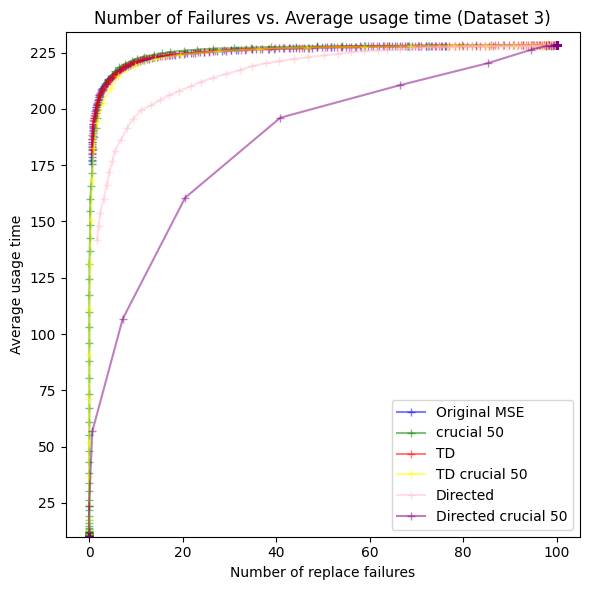

In [91]:
# Create a list of labels
custom_labels = ['Original MSE', 'crucial 50', 'TD', 'TD crucial 50', 'Directed', 'Directed crucial 50']

# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(6, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, result_df in enumerate(result_dfs):
    ax.plot(
        result_df['Number of replace failures'],
        result_df['Average usage time'], '+-',
        label=custom_labels[i],  # Use the custom label from the list
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')
ax.set_title('Number of Failures vs. Average usage time (Dataset 3)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

#ax.set_ylim(176,188) ### for dataset1
#ax.set_xlim(-0.5,60) ### for dataset1

ax.set_ylim(10,234) ### for dataset3
ax.set_xlim(-5,105) ### for dataset1,3


# Show the plot
plt.tight_layout()
plt.show()

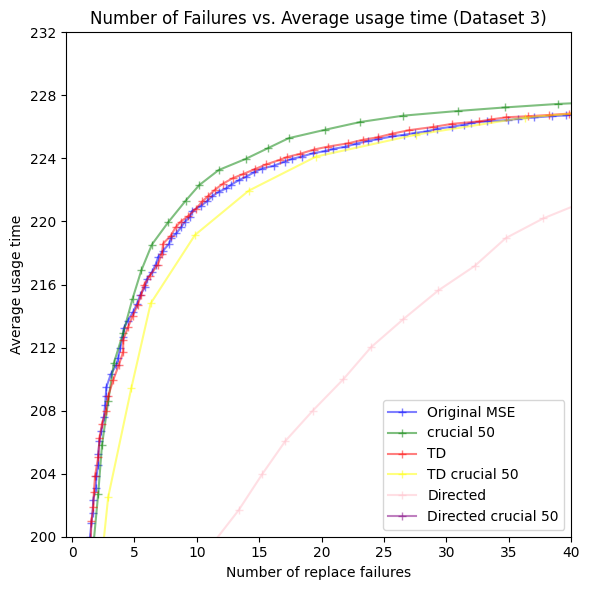

In [92]:
# Create a list of labels
custom_labels = ['Original MSE', 'crucial 50', 'TD', 'TD crucial 50', 'Directed', 'Directed crucial 50']

# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(6, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, result_df in enumerate(result_dfs):
    ax.plot(
        result_df['Number of replace failures'],
        result_df['Average usage time'], '+-',
        label=custom_labels[i],  # Use the custom label from the list
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')
ax.set_title('Number of Failures vs. Average usage time (Dataset 3)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

#ax.set_ylim(178,188) ### for dataset1
#ax.set_xlim(3,35) ### for dataset1

ax.set_ylim(200,232) ### for dataset3
ax.set_xlim(-0.5,40) ### for dataset3

# Show the plot
plt.tight_layout()
plt.show()

학습된 데이터 프레임을 csv로 저장

In [93]:
# CSV 파일로 저장
for idx, df in enumerate(result_dfs, start=1):
    df.to_csv(f"result_df_{idx}.csv")